# Abstrak
Dataset ini berisi spektrum inframerah (IR) — setiap sampel direpresentasikan oleh 1.800 titik nilai yang menunjukkan Dataset ini berisi spektrum inframerah, di mana setiap sampel direpresentasikan oleh 1.800 titik intensitas yang menggambarkan serapan cahaya pada berbagai panjang gelombang. Tugasnya adalah memprediksi lima target sekaligus, yaitu danger_1 sampai danger_5. Evaluasi menggunakan Mean Absolute Error dan skor utama adalah rata rata Mean Absolute Error di seluruh target.

Solusi yang digunakan memisahkan dua peran. Model bertugas menangkap pola dari spektrum, sedangkan post processing bertugas menyelaraskan prediksi dengan struktur label tiap target. Model utama adalah LightGBM dengan objective regresi L1 karena efisien untuk fitur tabular berdimensi besar dan selaras dengan metrik evaluasi. Fitur spektrum dinormalisasi per sampel menggunakan Standard Normal Variate untuk mengurangi efek perbedaan baseline dan skala antar sampel.

Peningkatan performa terbesar diperoleh dari snap yang dirancang spesifik per target. Untuk danger_1 digunakan pred space binning dengan 20 segmen dan pemetaan median agar prediksi lebih stabil pada level level yang sering muncul. Untuk danger_2 digunakan thresholding, di mana prediksi di bawah 0.183 dipetakan menjadi nol. Untuk danger_4 digunakan pemetaan ke lima level representatif dan empat threshold yang dituning untuk memproyeksikan prediksi kontinu menjadi level bertingkat yang konsisten. Untuk danger_5 digunakan pred space mapping dengan cross fit menggunakan 40 bin, lalu hasilnya dipaksa jatuh pada level yang benar benar muncul di data train. Sementara itu, danger_3 dibiarkan tanpa snap tambahan karena fokus perbaikan terbesar berasal dari target lain.

Studi ablation menunjukkan bahwa snap menurunkan rata rata Mean Absolute Error OOF dari 0.223334 menjadi 0.205213, dengan perbaikan terbesar pada danger_4 dan danger_5. Pipeline akhir tetap efisien untuk dijalankan pada CPU, karena inferensi cukup melatih satu model per target dan menggunakan konfigurasi snap yang sudah dikunci dari eksperimen

# Pendahuluan 
Penilaian keamanan kimia modern semakin banyak memanfaatkan pendekatan komputasional untuk mengidentifikasi pola risiko laten dari hasil pengukuran eksperimen. Pada kompetisi Chemical Danger Expression from IR Spectra, peserta ditantang membangun model machine learning yang mampu menginferensi ekspresi bahaya laten dari sinyal spektrum inframerah.

Peserta diberikan data spektrum IR yang merepresentasikan berbagai substansi kimia dan diminta memprediksi skor kemiripan kontinu. Skor ini menggambarkan seberapa kuat suatu substansi mengekspresikan serangkaian sifat bahaya laten. Sifat-sifat tersebut bersifat sintetis, namun dirancang untuk mencerminkan perilaku multifaktor yang realistis dan dapat diamati melalui pola spektral.

Tantangan utama pada data spektrum adalah karakter sinyal yang berdimensi tinggi dan sangat berkorelasi antar titik gelombang yang berdekatan, serta adanya variasi baseline dan skala antar sampel akibat perbedaan kondisi pengukuran. Di sisi target, tiap sifat bahaya dapat memiliki pola sebaran yang berbeda, sehingga model perlu menangkap hubungan spektral yang halus sekaligus menghasilkan prediksi yang stabil dan konsisten terhadap struktur label.

Notebook ini bertujuan menyusun alur kerja dari eksplorasi data, praproses spektrum, pemodelan, hingga evaluasi. Fokus utamanya adalah membangun model yang mampu mengekstraksi informasi dari bentuk spektrum dan memetakkannya menjadi prediksi skor kontinu untuk setiap sifat bahaya laten, dengan strategi validasi yang menjaga generalisasi serta analisis error untuk memahami area prediksi yang masih perlu diperbaiki.


# Studi Literatur
## Spektroskopi inframerah sebagai data berdimensi tinggi
Spektrum inframerah merepresentasikan respons serapan material terhadap panjang gelombang, sehingga tiap sampel memiliki banyak titik pengukuran yang saling berkorelasi kuat dan membentuk pola bentuk kurva. Karakter seperti ini membuat data spektrum mirip sinyal satu dimensi dengan struktur lokal seperti puncak, lembah, dan perubahan slope yang mengandung informasi komposisi. Literatur kemometri menekankan bahwa tantangan utama pada data spektrum bukan hanya jumlah fitur yang besar, tetapi juga variasi baseline, perbedaan skala antar sampel, serta korelasi tinggi antar wavelength yang dapat mengaburkan sinyal yang relevan jika tidak dinormalisasi.

## Normalisasi spektrum dengan Standard Normal Variate
Salah satu preprocessing yang umum pada data spektrum adalah Standard Normal Variate. SNV menormalisasi setiap sampel secara independen dengan mengurangkan rata rata intensitas dan membagi dengan standar deviasi intensitas pada sampel tersebut. Transformasi ini sering digunakan untuk mereduksi efek scatter, baseline shift, dan perbedaan skala antar sampel, sehingga model dapat lebih fokus pada bentuk relatif spektrum. Dalam konteks pemodelan berbasis fitur tabular, SNV juga membantu menstabilkan distribusi fitur sehingga algoritma pembelajaran lebih mudah menangkap pola yang konsisten lintas sampel. Rujukan praktik SNV banyak dibahas pada literatur kemometri dan analisis spektral, termasuk buku karya Barnes, Dhanoa, dan Lister 1989 serta tinjauan Savitzky dan Golay 1964 untuk konteks smoothing dan derivative.

## Ekstraksi bentuk dengan Savitzky Golay derivative
Selain normalisasi, turunan spektrum sering dipakai untuk menonjolkan informasi bentuk seperti perubahan slope dan pergeseran puncak. Metode Savitzky Golay menghasilkan smoothing sekaligus turunan berbasis fitting polinomial lokal, sehingga cukup populer untuk data spektrum karena mampu mengurangi noise sambil mempertahankan karakter puncak. Turunan pertama menonjolkan perubahan slope, sedangkan turunan kedua menonjolkan puncak dan lembah yang tajam. Meski demikian, derivative cenderung memperbesar noise pada region tertentu, sehingga pemilihan window length dan orde polinomial harus hati hati. Pada solusi ini, derivative diposisikan sebagai kandidat fitur yang dievaluasi melalui ablation, bukan asumsi wajib.

## Gradient boosting tree untuk data tabular berdimensi besar
Untuk model utama, gradient boosting decision tree merupakan pilihan yang sering dipakai pada data tabular dengan banyak fitur dan relasi non linear. LightGBM memperkenalkan optimasi histogram based dan strategi leaf wise growth untuk meningkatkan efisiensi komputasi sekaligus menjaga akurasi, terutama pada fitur banyak dan dataset menengah sampai besar. Ke et al. 2017 menunjukkan bahwa LightGBM dapat mencapai performa tinggi dengan biaya komputasi yang lebih efisien dibanding implementasi boosting lain pada banyak skenario. Karena metrik evaluasi pada tugas ini adalah MAE, penggunaan objective regresi L1 juga selaras dengan tujuan optimasi, sehingga model cenderung menghasilkan prediksi yang lebih robust terhadap outlier dibanding L2.

## Struktur label semi diskrit dan kebutuhan post processing
Pada banyak tugas regresi, label tidak selalu benar benar kontinu. Label dapat memiliki level dominan, batas level yang jelas, atau zero inflation, sehingga output regresi kontinu murni sering menghasilkan nilai antara level yang jarang muncul. Literatur kalibrasi dan post processing membahas bahwa pemetaan dari skor model ke prediksi akhir bisa meningkatkan keselarasan terhadap distribusi label, selama pemetaan tersebut dipelajari secara terkontrol untuk menghindari bias. Konsep ini berdekatan dengan histogram binning dan kalibrasi berbasis piecewise function pada probabilitas, serta memiliki hubungan dengan isotonic regression yang mempelajari fungsi monoton untuk memetakan skor menjadi output yang lebih terkalibrasi.

## Pemetaan pred-space binning sebagai bentuk kalibrasi sederhana
Pred-space binning membagi ruang prediksi menjadi beberapa segmen kuantil, lalu memetakan setiap segmen ke statistik ringkas target, seperti median. Pemetaan semacam ini dapat dilihat sebagai versi sederhana dari histogram binning, tetapi diterapkan pada output regresi untuk mengurangi fluktuasi kecil dan menempelkan prediksi pada level yang lebih representatif. Constraint monoton yang diterapkan pada level juga sejalan dengan ide isotonic mapping, yaitu menjaga agar pemetaan tidak menghasilkan urutan yang berlawanan secara global. Karena pemetaan ini ringan, ia cocok untuk pipeline kompetisi yang menuntut inferensi cepat.

## Thresholding untuk zero inflated target
Untuk target yang memiliki massa besar pada nol, thresholding adalah pendekatan yang umum. Alih alih membiarkan model regresi menghasilkan nilai kecil di sekitar nol yang memberi kontribusi error absolut, prediksi di bawah ambang tertentu dipetakan menjadi nol. Secara konsep, ini mendekati model dua tahap, yaitu memutuskan nol atau tidak nol, lalu memprediksi besaran pada kasus tidak nol. Implementasi thresholding di sini diposisikan sebagai post processing yang dituning berbasis prediksi OOF sehingga keputusan ambang tidak bias terhadap data train.

## Level mapping dan ordinal viewpoint
Untuk target bertingkat, memproyeksikan prediksi kontinu ke level level representatif dapat meningkatkan konsistensi. Literatur ordinal regression menekankan bahwa kelas memiliki urutan alami, sehingga kesalahan satu tingkat lebih kecil daripada kesalahan yang melompat jauh. McCullagh 1980 memperkenalkan model ordinal klasik, dan berbagai pendekatan modern mengeksplorasi cara memanfaatkan urutan tersebut. Dalam pipeline ini, pendekatan praktis yang dipakai adalah memilih level representatif berbasis median lalu men tune threshold pemisah antar level. Walaupun bukan ordinal regression murni, proses ini mengadopsi ide utama ordinal modelling, yaitu hasil akhir harus konsisten dengan struktur tingkat.

## Cross fitting untuk mengurangi bias saat post processing
Post processing yang dituning dari prediksi model berisiko mengalami bias jika pemetaan dipelajari menggunakan prediksi pada data yang sama yang dievaluasi. Cross fitting mengatasi masalah ini dengan cara mempelajari pemetaan pada train fold dan menerapkannya ke valid fold, sehingga prediksi yang dinilai tetap out of fold. Prinsip ini banyak digunakan dalam literatur evaluasi dan debiasing, karena menjaga agar transformasi yang dipelajari tidak memanfaatkan informasi label dari fold yang sedang dievaluasi.

## Validasi silang berbasis stratifikasi dengan binning
Stratified KFold bermanfaat untuk menjaga distribusi target per fold tetap seimbang. Namun stratifikasi standar lebih cocok untuk klasifikasi, sehingga pada regresi sering digunakan strategi binning target menjadi beberapa kelas semu, misalnya quantile bins. Pendekatan ini membantu mengurangi variansi antar fold dan membuat perbandingan eksperimen lebih adil, terutama ketika target memiliki distribusi yang timpang atau bertingkat.

# Preprocessing
Sebelum masuk ke modeling, ada beberapa langkah persiapan data yang perlu dilakukan. Setiap keputusan di bagian ini memiliki alasan yang berdampak pada kualitas model dan validitas evaluasi.

## 1. Load data

In [ ]:
# Install Dependencies
# Standard library
import os
import glob
import random
import time
import warnings
from typing import Dict, List, Tuple, Optional

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb

from scipy.signal import savgol_filter
from scipy.stats import f_oneway

# Scikit-learn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [86]:
warnings.filterwarnings("ignore", message="X does not have valid feature names*")
warnings.filterwarnings("ignore")

SEED = 42
TARGET_COLS = [f"danger_{i}" for i in range(1, 6)]
D1, D2, D3, D4, D5 = 0, 1, 2, 3, 4

def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)


train = pd.read_parquet("/kaggle/input/competitions/ristek-data-science-ai-2026-open-recruitment/train.parquet")
test  = pd.read_parquet("/kaggle/input/competitions/ristek-data-science-ai-2026-open-recruitment/test.parquet")
sub   = pd.read_csv("/kaggle/input/competitions/ristek-data-science-ai-2026-open-recruitment/sample_submission.csv")

In [87]:
# --- spec columns
def sort_spec_cols(cols):
    return sorted(cols, key=lambda s: int(s.split("_")[1]))

SPEC_COLS = sort_spec_cols([c for c in train.columns if c.startswith("spec_")])

print("train shape:", train.shape)
print("test shape :", test.shape)
print("n_spec:", len(SPEC_COLS))
print("targets:", TARGET_COLS)

train.head()


train shape: (10765, 1806)
test shape : (2153, 1801)
n_spec: 1800
targets: ['danger_1', 'danger_2', 'danger_3', 'danger_4', 'danger_5']


,index,danger_1,danger_2,danger_3,danger_4,danger_5,spec_0,spec_1,spec_2,spec_3,...,spec_1790,spec_1791,spec_1792,spec_1793,spec_1794,spec_1795,spec_1796,spec_1797,spec_1798,spec_1799
0,6355,0.998099,0.000000,0.412130,2.007870,1.096536,0.020486,0.004148,0.016626,0.008192,...,-0.000462,0.000096,-0.000429,0.000083,-0.000435,0.000079,-0.000440,0.000104,-0.000429,0.000060
1,2018,0.799195,0.396678,0.699549,4.009217,1.092716,0.027620,0.018637,0.025863,0.018282,...,-0.007534,0.007039,-0.007408,0.007004,-0.007333,0.007210,-0.007453,0.006955,-0.007435,0.006918
2,8485,0.807661,1.002305,0.392580,3.003408,1.393353,0.000234,0.002530,0.002768,0.003118,...,0.000126,0.000897,0.000100,0.000482,0.000141,0.000342,0.000061,0.000385,0.000150,0.000408
3,10052,0.809439,0.388675,0.406778,2.990858,1.102664,0.038080,0.015747,0.027870,0.010491,...,0.001568,-0.001610,0.001610,-0.001593,0.001598,-0.001621,0.001648,-0.001648,0.001600,-0.001555
4,9933,0.306516,0.000000,0.000000,3.011504,0.590741,0.089806,0.075439,0.078480,0.069992,...,-0.036597,0.022802,0.009044,-0.008531,-0.010287,0.009247,0.014202,-0.035784,-0.002160,-0.061648


Dataset training terdiri dari 10.765 sampel dengan 1.800 kolom spektrum dan 5 kolom target, sementara data test terdiri dari 2.153 sampel dengan kolom spektrum yang sama tanpa kolom target. Rasio train-test sekitar 5:1, cukup memadai untuk training model yang stabil.

Setelah data berhasil dibaca, beberapa hal langsung dicek. Pertama, kolom spektrum diidentifikasi dan diurutkan berdasarkan indeks numeriknya (spec_0 sampai spec_1799). Pengurutan eksplisit ini penting untuk memastikan konsistensi antara train dan test karena jika urutannya berbeda, model akan memetakan fitur ke kolom yang salah. Pengecekan bahwa kolom spektrum di train dan test identik dilakukan sebelum proses berlanjut; jika ada ketidaksesuaian, proses akan langsung berhenti dengan pesan error yang jelas.

Dari sekilas melihat data, nilai spektrum berada di orde yang sangat kecil (sekitar 0.001 hingga 0.09) dan sebagian ada yang bernilai negatif. Ini adalah karakteristik khas spektrum IR yang sudah melalui preprocessing instrumen, bukan anomali. Nilai target di training bervariasi antar sampel dan antar target, dengan pola yang akan dibahas lebih detail di bagian EDA.

In [88]:
# Check for null values
def check_nulls(df):
    nulls = df.isnull().sum()
    nulls_percentage = (nulls / len(df)) * 100
    return pd.DataFrame({'nulls': nulls, 'nulls_percentage': nulls_percentage})

train_nulls = check_nulls(train)
test_nulls = check_nulls(test)

print("Train Null Values:")
print(train_nulls[train_nulls['nulls'] > 0])
print("\nTest Null Values:")
print(test_nulls[test_nulls['nulls'] > 0])

Train Null Values:
Empty DataFrame
Columns: [nulls, nulls_percentage]
Index: []

Test Null Values:
Empty DataFrame
Columns: [nulls, nulls_percentage]
Index: []


Hasil menunjukkan bahwa kedua dataset tersebut tidak memiliki nilai null, sehingga tidak diperlukan penanganan nilai hilang atau imputasi data sebelum melanjutkan ke tahap pemrosesan data atau pelatihan model.

## 2. Sanity Check
Sanity check untuk memastikan bahwa kolom spektrum pada data train dan test memiliki kesamaan, baik dari segi nama maupun urutannya. Selanjutnya, seluruh array dikonversi menjadi tipe data float32 guna menghemat memori dan mempercepat proses komputasi. Selain itu, pada tahap ini juga dihitung nilai minimum dan maksimum setiap target dari data training yang nantinya akan digunakan sebagai batas clipping pada prediksi.

In [89]:
# Sanity check
SPEC_COLS_TEST = sort_spec_cols([c for c in test.columns if c.startswith("spec_")])

# Build arrays
X_tr  = train[SPEC_COLS].to_numpy(dtype=np.float32)
X_te  = test[SPEC_COLS].to_numpy(dtype=np.float32)
y_all = train[TARGET_COLS].to_numpy(dtype=np.float32)

y_min = y_all.min(axis=0).astype(np.float32)
y_max = y_all.max(axis=0).astype(np.float32)

print("X_tr  :", X_tr.shape,  X_tr.dtype)
print("X_te  :", X_te.shape,  X_te.dtype)
print("y     :", y_all.shape, y_all.dtype)
print("y_min :", y_min)
print("y_max :", y_max)


X_tr  : (10765, 1800) float32
X_te  : (2153, 1800) float32
y     : (10765, 5) float32
y_min : [0. 0. 0. 0. 0.]
y_max : [1.3124306 1.0124788 1.0121185 4.012463  1.4123765]


Hasil sanity check menunjukkan data sudah rapi untuk tahap analisis awal. Target lengkap lima kolom dengan nilai minimum nol untuk semua target dan nilai maksimum berada pada rentang wajar, dengan danger 4 paling besar sehingga tampak berbeda skala dibanding target lain.

## 3. Rentang Nilai per Target

Kita cek rentang serta karakter sebaran nilai target dengan boxplot per kolom danger. Plot ini membantu kita melihat median, lebar sebaran utama, dan keberadaan outlier, sambil menampilkan nilai minimum dan maksimum agar perbedaan skala antar target langsung terbaca.

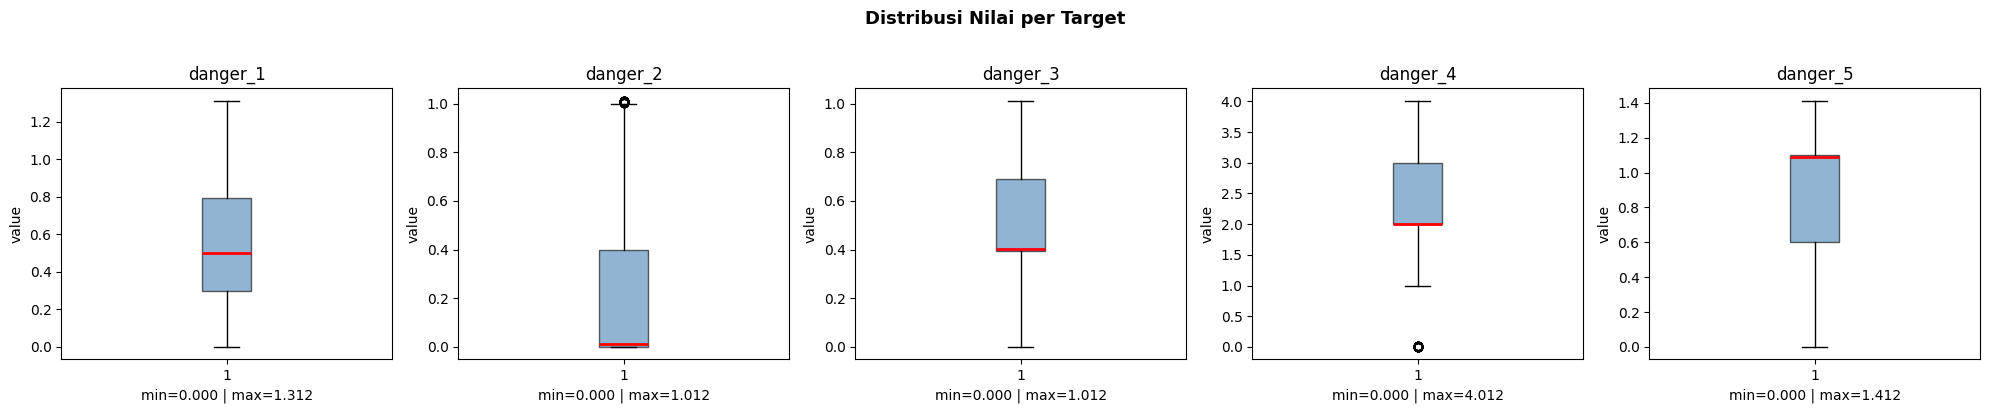

In [90]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, c in enumerate(TARGET_COLS):
    axes[i].boxplot(y_all[:, i], patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6),
                    medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(c)
    axes[i].set_ylabel("value")
    axes[i].set_xlabel(f"min={y_min[i]:.3f} | max={y_max[i]:.3f}")
plt.suptitle("Distribusi Nilai per Target", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Terlihat bahwa tiap target punya karakter yang beda. Danger 1, danger 3, dan danger 5 berada di rentang sekitar nol sampai sedikit di atas satu, dengan sebaran yang cukup lebar sehingga variasinya bukan cuma di dekat nol. Median danger 1 dan danger 3 ada di kisaran menengah, sementara danger 5 cenderung lebih tinggi karena median dan kuartilnya bergeser ke atas dibanding dua target itu.

Danger 2 terlihat sangat berat ke bawah karena box dan median menempel dekat nol, lalu ada ekor panjang sampai mendekati satu yang menunjukkan hanya sebagian kecil sampel yang punya nilai besar. Danger 4 punya skala jauh lebih besar sampai sekitar empat dengan median di sekitar dua dan sebaran utama cukup lebar, serta terlihat ada nilai yang sangat rendah mendekati nol yang muncul sebagai outlier. Ini mengonfirmasi bahwa perbedaan skala dan bentuk distribusi antar target cukup kuat, jadi perlakuan antar target memang tidak bisa disamakan begitu saja.

## Kesimpulan Preprocessing

Tahap preprocessing memastikan data siap masuk ke modelling tanpa pembersihan berat. Train dan test tidak memiliki nilai null sehingga tidak diperlukan imputasi. Konsistensi fitur juga divalidasi dengan memastikan kolom spektrum train dan test identik serta berurutan, lalu seluruh array dikonversi ke float32 untuk efisiensi komputasi. Sebagai persiapan evaluasi yang valid, nilai minimum dan maksimum tiap target dari data training dihitung untuk kebutuhan clipping prediksi pada tahap modelling. 

# EDA

Setelah data siap, langkah berikutnya adalah memahami karakteristik data secara lebih dalam.

## 1. Statistik Deskriptif

kita lihat ringkasan statistik tiap target secara numerik. Ini memberikan gambaran awal yang objektif sebelum interpretasi visual.

In [91]:
# Statistik deskriptif target
desc = pd.DataFrame(y_all, columns=TARGET_COLS).describe().T
desc["skewness"] = pd.DataFrame(y_all, columns=TARGET_COLS).skew()
desc["zero_rate"] = (y_all == 0).mean(axis=0)
desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", 
             "skewness", "zero_rate"]]
desc = desc.round(4)
display(desc)

,count,mean,std,min,25%,50%,75%,max,skewness,zero_rate
danger_1,10765.0,0.4899,0.2898,0.0,0.3005,0.4999,0.7927,1.3124,-0.1114,0.0770
danger_2,10765.0,0.1976,0.2099,0.0,0.0000,0.0113,0.3997,1.0125,0.3782,0.2635
danger_3,10765.0,0.4548,0.1792,0.0,0.3942,0.4040,0.6897,1.0121,-0.3244,0.0322
danger_4,10765.0,2.3829,0.7507,0.0,1.9954,2.0089,2.9994,4.0125,0.0275,0.0015
danger_5,10765.0,0.8687,0.2874,0.0,0.6003,1.0908,1.1020,1.4124,-0.5647,0.0001


Beberapa hal yang terlihat dari tabel ini yaitu, danger_4 memiliki rentang nilai terbesar (0–4.01) dengan mean 2.38 dan median 2.09 yang mengkonfirmasi sifat ordinalnya, distribusinya terpusat di kelas tengah (2 dan 3), konsisten dengan temuan imbalance yang akan dibahas lebih lanjut. danger_2 memiliki zero rate tertinggi sebesar 26.35%, hampir sepertiga dari seluruh sampel bernilai nol, ini menjadi bahan pertimbangan untuk langkah thresholding di post-processing. danger_5 menyusul dengan zero rate 0.01% yang jauh lebih kecil, sementara danger_3 dan danger_1 hampir tidak memiliki nilai nol sama sekali.

Dari sisi skewness, danger_3 memiliki skewness negatif paling ekstrem (-3.24) yang mengindikasikan mayoritas sampel berada di nilai tinggi dengan sedikit sampel di nilai rendah — pola yang berlawanan dengan target lainnya. danger_4 memiliki skewness mendekati nol (0.03) yang konsisten dengan distribusi ordinal yang relatif seimbang di kelas tengah. danger_1 dan danger_5 memiliki skewness negatif moderat, menunjukkan distribusi yang condong ke nilai tinggi.
    
Secara keseluruhan, perbedaan karakteristik yang cukup mencolok antar target ini mengkonfirmasi bahwa pendekatan post-processing yang seragam tidak akan optimal — setiap target perlu diperlakukan secara berbeda, yang menjadi landasan utama desain snap per target di pipeline ini.

## 2. Histogram Semua Target

Langkah pertama dalam memahami target adalah melihat bagaimana nilai tiap target terdistribusi. Distribusi yang berbeda-beda antar target mengindikasikan bahwa pendekatan post-processing yang seragam tidak akan optimal — setiap target perlu diperlakukan secara berbeda sesuai karakteristiknya.

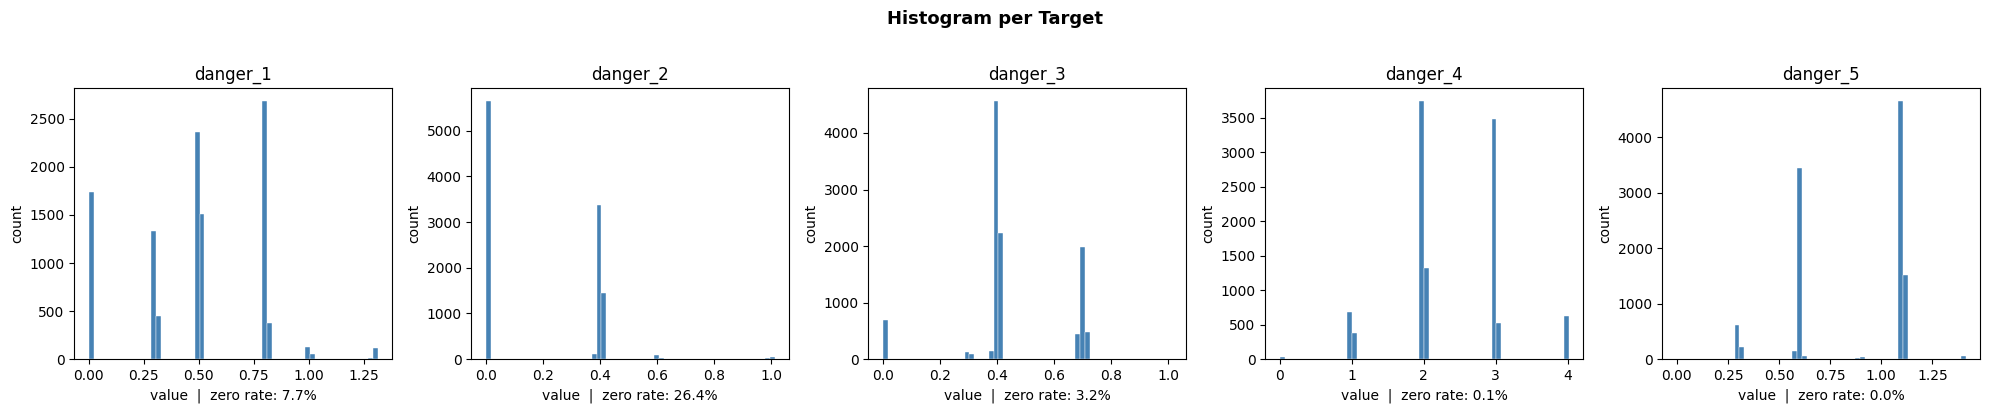

In [2]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, c in enumerate(TARGET_COLS):
    axes[i].hist(y_all[:, i], bins=60, color="steelblue",
                 edgecolor="white", linewidth=0.3)
    axes[i].set_title(c)
    axes[i].set_xlabel("value")
    axes[i].set_ylabel("count")
    zero_rate = float((y_all[:, i] == 0).mean())
    axes[i].set_xlabel(f"value  |  zero rate: {zero_rate:.1%}")
plt.suptitle("Histogram per Target", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Histogram menunjukkan bahwa distribusi target kita cenderung tidak benar - benar kontinu karena hampir semua target punya puncak yang tajam di nilai nilai tertentu, seolah labelnya berasal dari level-level diskrit atau hasil pembulatan. Danger 1 terlihat punya beberapa puncak besar di rentang menengah dengan zero rate sekitar 7,7 persen sehingga masih ada massa nol yang cukup terasa tetapi bukan yang dominan. Danger 3 lebih rapat di beberapa level tertentu dengan zero rate sekitar 3,2 persen sehingga mayoritas nilainya berada di level non nol. Danger 4 paling khas karena massanya terkonsentrasi kuat di sekitar beberapa level utama pada skala dua sampai tiga dan hampir tidak punya nol dengan zero rate sekitar 0,1 persen sehingga memang wajar jika target ini berperilaku seperti ordinal bertingkat. Danger 5 terlihat sangat bertingkat juga dengan puncak besar di sekitar dua level dominan dan zero rate nol persen sehingga nyaris seluruh sampel berada pada nilai positif.

Danger 2 terlihat ekstrim, karena *zero-rate* mencapai sekitar 26,4 persen dan histogramnya menumpuk sangat besar di nol lalu meloncat ke satu dua level lain dengan frekuensi jauh lebih kecil, jadi ini jelas pola zero inflation yang kuat. Secara analisis awal, kombinasi puncak tajam dan zero rate yang berbeda beda ini mengindikasikan bahwa tiap target punya mekanisme label yang berbeda, sehingga pendekatan per target seperti perlakuan khusus untuk nol pada danger 2 dan perlakuan ordinal bertingkat pada danger 4 sangat masuk akal jika nanti kita masuk ke tahap pemodelan.

## 3. Scatter Matrix Antar Target

Setelah kita paham bentuk distribusi masing masing target secara terpisah, langkah berikutnya adalah melihat hubungan antar target lewat scatter matrix. Di sini kita bungkus seluruh label danger_1 sampai danger_5 ke dalam sebuah DataFrame, lalu membuat grid lima kali lima agar setiap pasangan target bisa dibandingkan langsung. Panel diagonal menampilkan histogram tiap target sebagai pengingat bentuk distribusinya, sedangkan panel di luar diagonal menampilkan scatter untuk melihat apakah ada korelasi, pola non linear, pengelompokan level, atau struktur bertingkat yang konsisten antar dua target. Visualisasi ini berguna di tahap analisis awal untuk mengecek apakah beberapa target saling terkait kuat sehingga mungkin ada sinyal bersama, atau justru relatif independen sehingga lebih masuk akal diperlakukan sebagai masalah per target tanpa asumsi hubungan yang kuat.

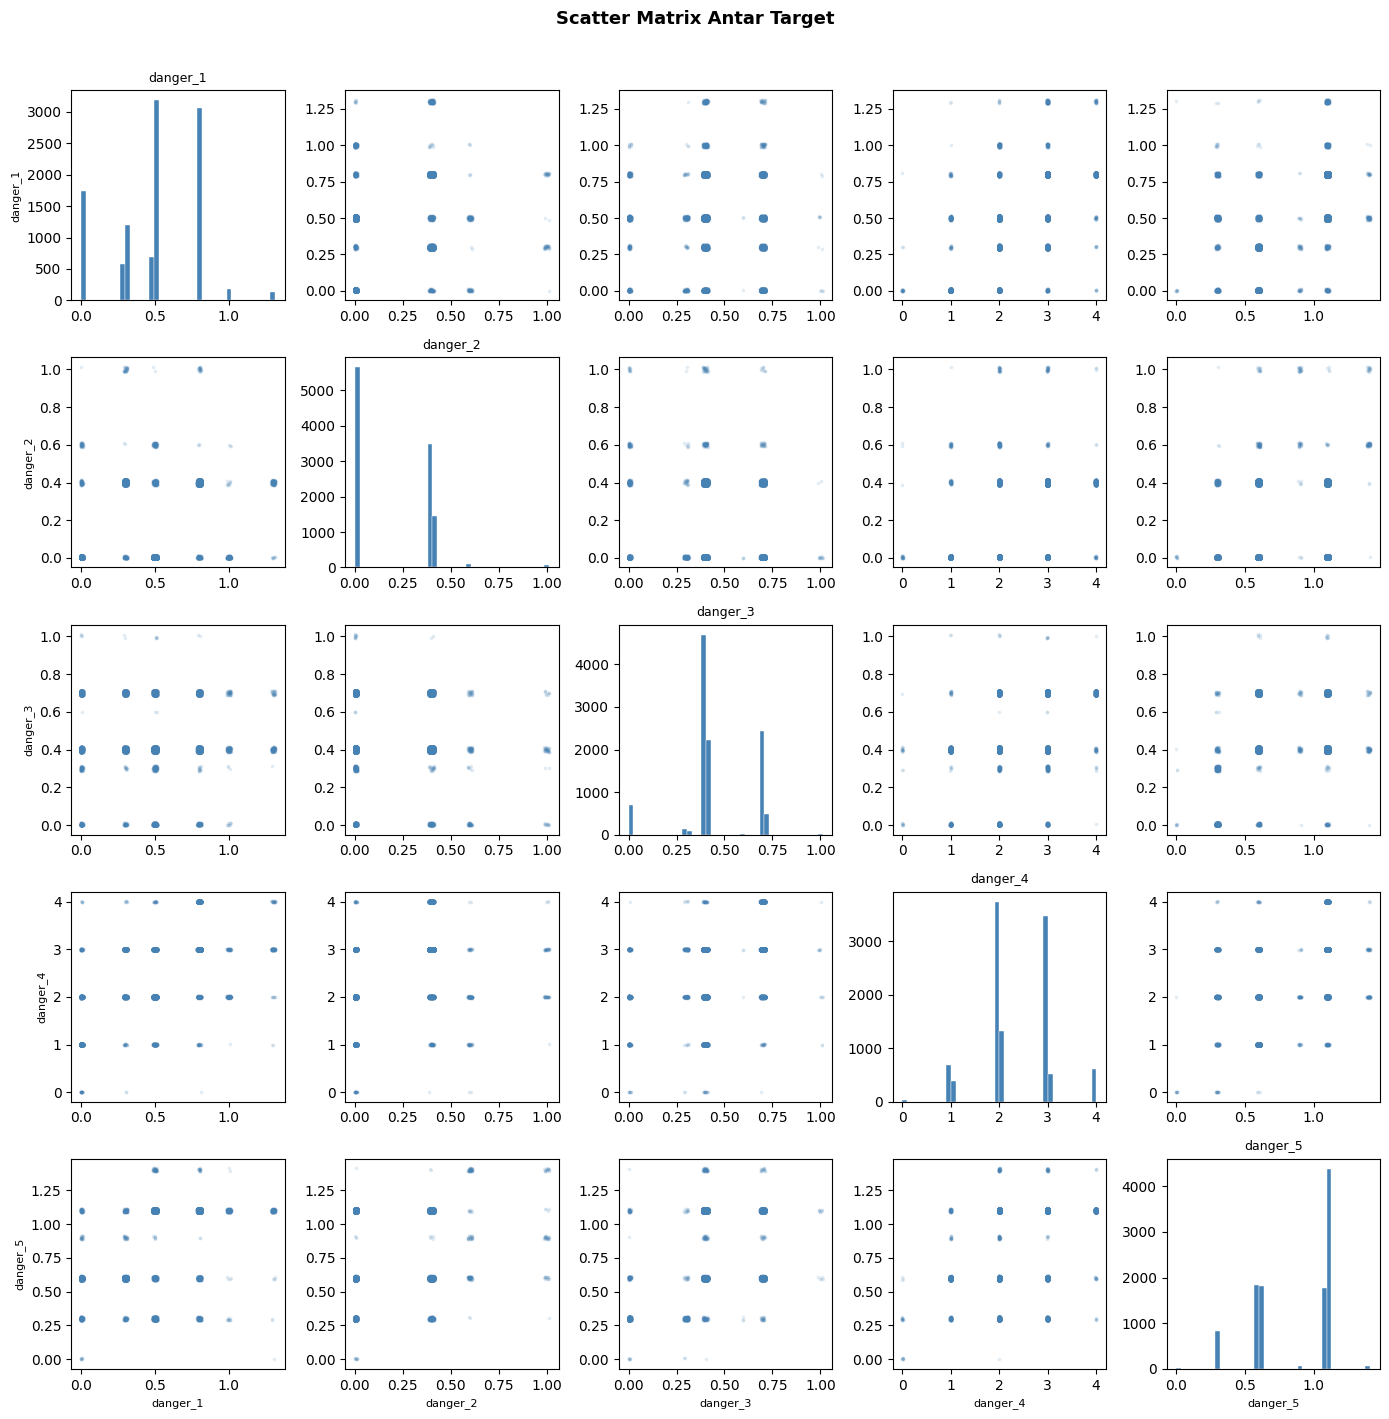

In [93]:
df_targets = pd.DataFrame(y_all, columns=TARGET_COLS)

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
for i in range(5):
    for j in range(5):
        ax = axes[i][j]
        if i == j:
            ax.hist(df_targets.iloc[:, i], bins=40,
                    color="steelblue", edgecolor="white", linewidth=0.3)
            ax.set_title(TARGET_COLS[i], fontsize=9)
        else:
            ax.scatter(df_targets.iloc[:, j], df_targets.iloc[:, i],
                       alpha=0.1, s=3, color="steelblue")
        if j == 0: ax.set_ylabel(TARGET_COLS[i], fontsize=8)
        if i == 4: ax.set_xlabel(TARGET_COLS[j], fontsize=8)
plt.suptitle("Scatter Matrix Antar Target", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Dari scatter matrix ini terlihat bahwa kelima target tidak bergerak sebagai variabel kontinu murni, melainkan cenderung mengambil nilai pada level level tertentu sehingga titik titiknya membentuk pola kisi berupa garis vertikal dan horizontal. Pola ini konsisten dengan histogram sebelumnya yang menunjukkan puncak tajam di beberapa nilai, jadi hubungan antar target pun muncul sebagai kombinasi level, bukan sebaran awan yang halus. 

Danger 2 tampak paling berbeda karena banyak massa berada di nol, sehingga pada pasangan mana pun ia sering membentuk garis padat di nilai nol dan sisanya hanya muncul pada sedikit level non nol. 

Danger 4 juga jelas bertingkat pada skala lebih besar dan di banyak pasangan tidak memperlihatkan kemiringan diagonal yang kuat, jadi indikasi korelasi linear antar target secara umum terlihat lemah sampai sedang. Secara analisis awal, ini menyiratkan bahwa sinyal antar target lebih berupa keterkaitan kasar pada level tertentu daripada hubungan kontinu yang kuat, sehingga lebih aman menganggap tiap target punya karakter sendiri sambil tetap membuka kemungkinan ada asosiasi ringan pada beberapa pasangan.

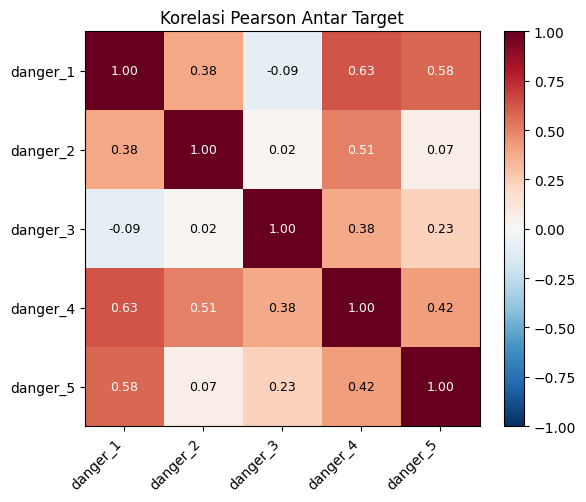

In [94]:
corr = df_targets.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(im, ax=ax)
ax.set_xticks(range(5)); ax.set_xticklabels(TARGET_COLS, rotation=45, ha="right")
ax.set_yticks(range(5)); ax.set_yticklabels(TARGET_COLS)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                fontsize=9, color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
ax.set_title("Korelasi Pearson Antar Target")
plt.tight_layout()
plt.show()

Heatmap korelasi Pearson ini merangkum apa yang tadi terlihat di scatter matrix, yaitu ada beberapa hubungan yang cukup jelas tetapi tidak semuanya kuat. Hubungan paling tinggi muncul antara danger 1 dan danger 4 dengan korelasi sekitar 0,63, lalu danger 1 dan danger 5 sekitar 0,58, yang mengindikasikan ketika danger 1 naik biasanya danger 4 dan danger 5 juga cenderung ikut naik. Danger 2 punya korelasi sedang dengan danger 4 sekitar 0,51 dan korelasi sedang dengan danger 1 sekitar 0,38, tetapi hampir tidak berkorelasi dengan danger 3 dan danger 5 sehingga perilakunya relatif lebih “sendiri” dibanding target lain. Danger 3 juga terlihat paling independen karena korelasinya kecil terhadap sebagian besar target, bahkan sedikit negatif dengan danger 1 sekitar minus 0,09. Pola ini memberi sinyal bahwa ada klaster keterkaitan yang cukup kuat di sekitar danger 4 sebagai target yang “terhubung” dengan beberapa target lain, sementara danger 3 dan terutama hubungan yang melibatkan danger 2 dengan danger 5 tampak lemah, jadi tidak ada alasan kuat untuk mengasumsikan semua target berbagi sinyal yang sama.

## 4. Analisis Spektrum
Setelah memahami karakteristik target, langkah berikutnya adalah melihat dari sisi fitur, bagaimana bentuk spektrum itu sendiri dan apakah informasi yang dibutuhkan untuk membedakan tiap target memang ada di data. Ini penting untuk memvalidasi bahwa pendekatan berbasis spektrum masuk akal sebelum kita memutuskan transformasi dan arsitektur model yang akan digunakan.

### A. Spektrum Raw

Langkah pertama dalam menganalisis fitur adalah melihat bentuk spektrum secara langsung. Visualisasi beberapa sampel acak memberikan gambaran awal tentang seberapa besar variasi antar sampel — apakah perbedaannya hanya soal skala dan baseline, atau memang ada perbedaan bentuk yang lebih fundamental.

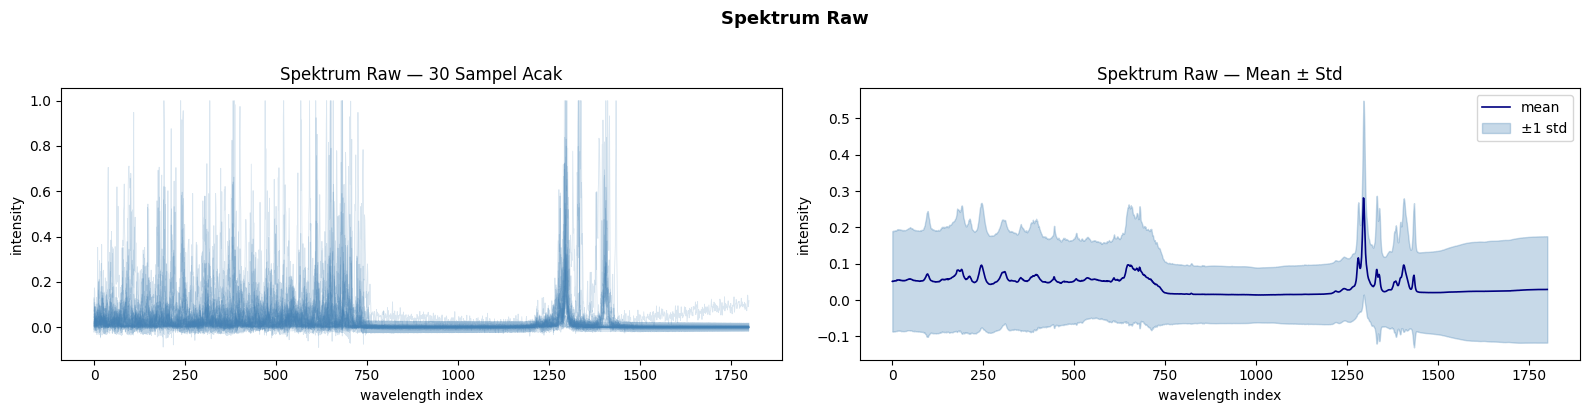

In [95]:
wavelength  = np.arange(len(SPEC_COLS))
idx_sample  = np.random.choice(len(X_tr), 30, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 30 sampel acak
for i in idx_sample:
    axes[0].plot(wavelength, X_tr[i], alpha=0.2, linewidth=0.6, color="steelblue")
axes[0].set_title("Spektrum Raw — 30 Sampel Acak")
axes[0].set_xlabel("wavelength index")
axes[0].set_ylabel("intensity")

# Mean ± std
mean_spec = X_tr.mean(axis=0)
std_spec  = X_tr.std(axis=0)
axes[1].plot(wavelength, mean_spec, color="navy", linewidth=1.2, label="mean")
axes[1].fill_between(wavelength,
                     mean_spec - std_spec,
                     mean_spec + std_spec,
                     alpha=0.3, color="steelblue", label="±1 std")
axes[1].set_title("Spektrum Raw — Mean ± Std")
axes[1].set_xlabel("wavelength index")
axes[1].set_ylabel("intensity")
axes[1].legend()

plt.suptitle("Spektrum Raw", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


Plot spektrum raw ini memberi gambaran awal bahwa sinyal tidak seragam sepanjang wavelength dan ada beberapa wilayah yang jauh lebih bervariasi dibanding yang lain. Di panel kiri terlihat sebagian besar kurva berada di intensitas rendah dengan banyak spike tajam pada rentang awal hingga sekitar pertengahan, lalu ada area yang relatif tenang, dan kemudian muncul lonjakan besar yang sangat menonjol di sekitar indeks 1.200–1.300. Ini menunjukkan variasi antar sampel cukup besar dan ada wilayah wavelength tertentu yang sering memunculkan puncak ekstrem.

Ringkasan di panel kanan menguatkan hal tersebut — garis mean relatif datar pada banyak bagian, tetapi terdapat perubahan pola yang jelas di sekitar indeks 700–800 dan puncak mean yang tajam di sekitar 1.200. Pita ±1 standar deviasi juga melebar pada area yang sama, artinya variabilitas antar sampel paling tinggi terkonsentrasi di wilayah tersebut. Ini menyiratkan bahwa sebagian fitur membawa sinyal kuat sekaligus noise yang tinggi, sehingga normalisasi per sampel seperti SNV menjadi masuk akal untuk meredam perbedaan skala antar spektrum dan membuat model lebih fokus pada bentuk relatif daripada amplitudo absolut.

### B. SNV vs Raw
Dari visualisasi spektrum raw, terlihat bahwa variasi baseline dan skala antar sampel cukup besar. SNV (Standard Normal Variate) menangani masalah ini dengan menormalisasi setiap sampel secara independen, mengurangkan mean dan membagi dengan standar deviasi baris. Hasilnya, perbedaan amplitudo global antar sampel dihilangkan dan yang tersisa adalah pola bentuk spektrum yang lebih murni. Visualisasi berikut membandingkan spektrum sebelum dan sesudah transformasi SNV.

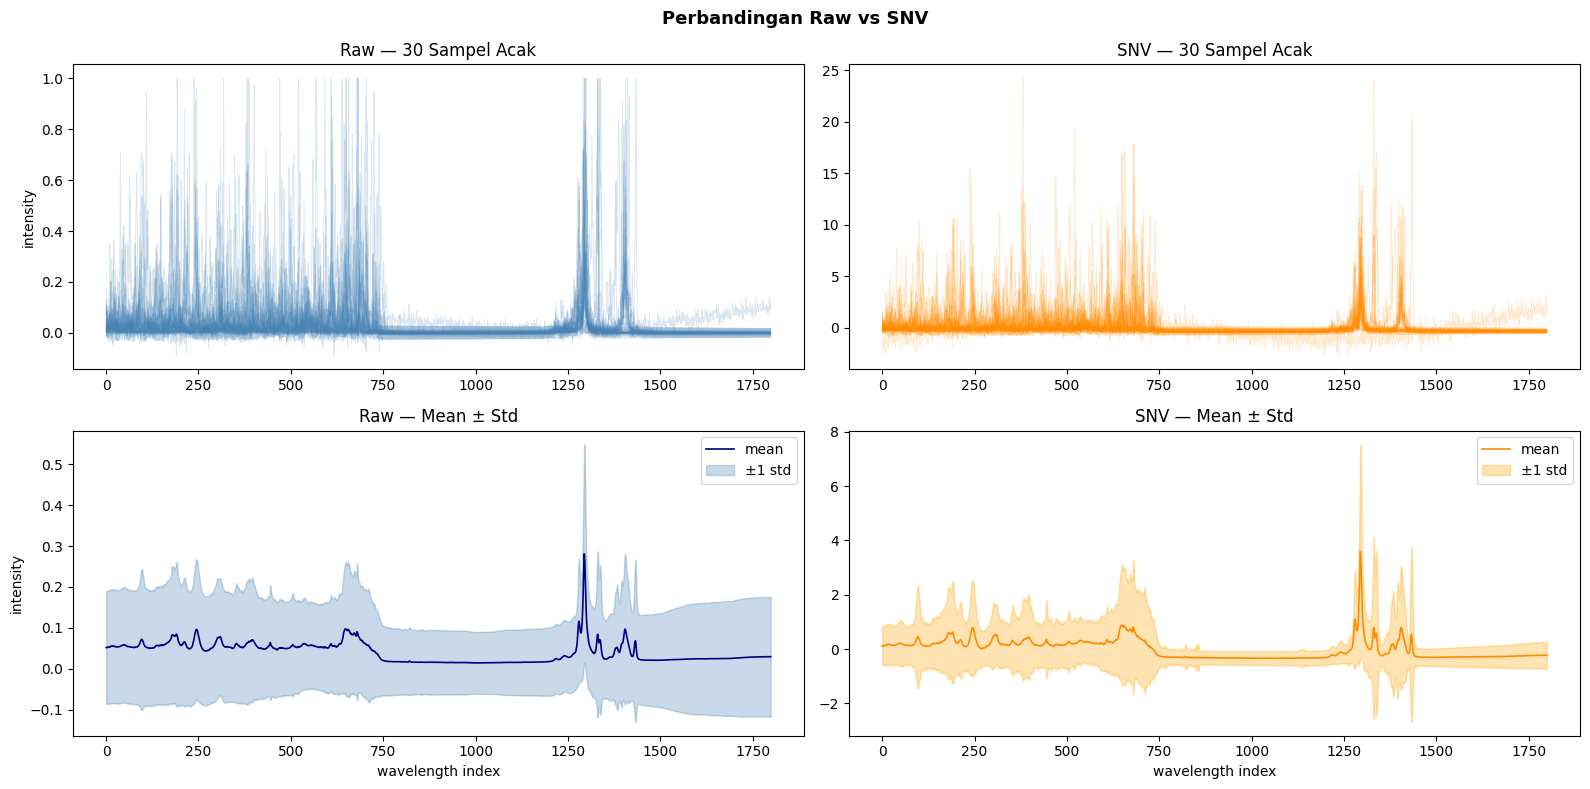

In [96]:
def snv_transform(X, eps=1e-12):
    """
    Standard Normal Variate (SNV) per sample (baris).
    X: array (n_samples, n_features)
    """
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + eps)

X_tr_snv = snv_transform(X_tr)
X_te_snv = snv_transform(X_te)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Raw — 30 sampel
for i in idx_sample:
    axes[0][0].plot(wavelength, X_tr[i], alpha=0.2, linewidth=0.6, color="steelblue")
axes[0][0].set_title("Raw — 30 Sampel Acak")
axes[0][0].set_ylabel("intensity")

# SNV — 30 sampel
for i in idx_sample:
    axes[0][1].plot(wavelength, X_tr_snv[i], alpha=0.2, linewidth=0.6, color="darkorange")
axes[0][1].set_title("SNV — 30 Sampel Acak")

# Raw — Mean ± std
axes[1][0].plot(wavelength, X_tr.mean(axis=0), color="navy", linewidth=1.2, label="mean")
axes[1][0].fill_between(wavelength,
                        X_tr.mean(axis=0) - X_tr.std(axis=0),
                        X_tr.mean(axis=0) + X_tr.std(axis=0),
                        alpha=0.3, color="steelblue", label="±1 std")
axes[1][0].set_title("Raw — Mean ± Std")
axes[1][0].set_ylabel("intensity")
axes[1][0].set_xlabel("wavelength index")
axes[1][0].legend()

# SNV — Mean ± std
axes[1][1].plot(wavelength, X_tr_snv.mean(axis=0), color="darkorange", linewidth=1.2, label="mean")
axes[1][1].fill_between(wavelength,
                        X_tr_snv.mean(axis=0) - X_tr_snv.std(axis=0),
                        X_tr_snv.mean(axis=0) + X_tr_snv.std(axis=0),
                        alpha=0.3, color="orange", label="±1 std")
axes[1][1].set_title("SNV — Mean ± Std")
axes[1][1].set_xlabel("wavelength index")
axes[1][1].legend()

plt.suptitle("Perbandingan Raw vs SNV", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Di panel raw (kiri), kurva 30 sampel acak terlihat sangat beragam dalam hal amplitudo — ada sampel yang intensitasnya mendekati 1.0 dan ada yang hampir datar di sekitar nol, dengan puncak tajam yang dominan di sekitar indeks 1.300. Setelah transformasi SNV (kanan), perbedaan amplitudo global antar sampel berkurang secara signifikan dan kurva-kurva menjadi lebih "sejajar" satu sama lain, meskipun pola puncak di wilayah yang sama tetap terlihat.

Panel mean ± std di baris bawah memperlihatkan perubahan yang lebih jelas. Pada raw, mean memiliki baseline yang tidak nol dan pita standar deviasi cukup lebar terutama di rentang 0–700 dan sekitar 1.300. Setelah SNV, mean mendekati nol di sebagian besar wilayah dan pita standar deviasi menyempit, yang mengindikasikan bahwa variasi yang sebelumnya disebabkan oleh perbedaan skala antar sampel berhasil diredam. Namun perlu dicatat bahwa puncak di sekitar indeks 1.300 tetap menonjol bahkan setelah SNV — ini mengindikasikan bahwa variasi di wilayah tersebut memang berasal dari perbedaan komposisi sampel yang nyata, bukan sekadar artefak skala.

Dari perbandingan ini, SNV terbukti efektif mengurangi efek baseline dan skala, sehingga model dapat lebih fokus pada pola bentuk spektrum yang informatif. Inilah alasan SNV dipakai sebagai preprocessing untuk sebagian besar target (danger_1, danger_2, danger_4, danger_5), sementara danger_3 tetap menggunakan raw karena eksperimen menunjukkan hasil yang lebih baik tanpa transformasi.

### C. Heatmap Spektrum
Untuk mendapatkan gambaran yang lebih menyeluruh, seluruh dataset training divisualisasikan sekaligus dalam bentuk heatmap, setiap baris merepresentasikan satu sampel, setiap kolom merepresentasikan satu titik wavelength, dan warna merepresentasikan intensitas. Heatmap ini ditampilkan dalam urutan asli data tanpa sorting, sehingga yang terlihat adalah variasi spektrum secara umum di seluruh dataset, seberapa konsisten pola antar sampel dan di wilayah wavelength mana variasi paling besar terjadi.

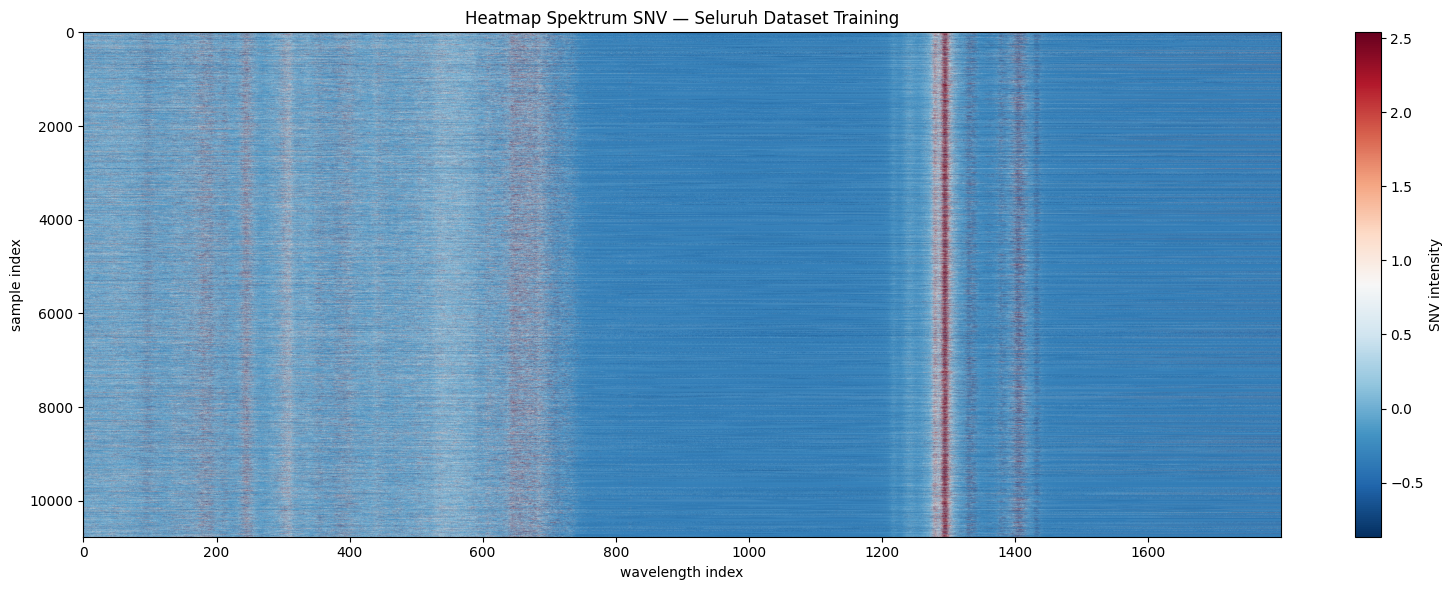

In [97]:
# Heatmap spektrum — urutan asli, tanpa sorting
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(X_tr_snv, aspect="auto", cmap="RdBu_r",
               vmin=np.percentile(X_tr_snv, 2),
               vmax=np.percentile(X_tr_snv, 98))
plt.colorbar(im, ax=ax, label="SNV intensity")
ax.set_xlabel("wavelength index")
ax.set_ylabel("sample index")
ax.set_title("Heatmap Spektrum SNV — Seluruh Dataset Training")
plt.tight_layout()
plt.show()

Heatmap ini memperlihatkan beberapa pola yang menarik. Secara umum, sebagian besar spektrum berwarna biru muda yang seragam, menandakan intensitas SNV yang rendah dan relatif konsisten di mayoritas wavelength. Namun ada beberapa kolom vertikal yang menonjol dengan warna berbeda, yang mengindikasikan wilayah wavelength dengan variasi tinggi di seluruh dataset.

Paling mencolok adalah dua garis vertikal merah pekat di sekitar indeks 1.300 dan 1.400 yang terlihat konsisten di hampir semua sampel, ini adalah wilayah puncak absorpsi yang sangat kuat dan muncul di hampir setiap sampel. Selain itu, area sekitar indeks 0–700 menunjukkan warna yang lebih terang dan lebih bervariasi dibanding area 800–1.200 yang relatif seragam dan tenang.

Yang paling informatif dari heatmap ini adalah bahwa pola vertikal yang muncul konsisten di seluruh 10.765 sampel — tidak ada sampel yang terlihat sebagai outlier ekstrem dengan pola yang sama sekali berbeda dari yang lain. Ini mengindikasikan bahwa dataset cukup homogen secara struktural, dan variasi antar sampel lebih bersifat kuantitatif (seberapa kuat puncaknya) daripada kualitatif (apakah puncaknya ada atau tidak). Temuan ini memperkuat asumsi bahwa model berbasis spektrum seharusnya bisa belajar pola yang konsisten dari data ini.
<hr>

Heatmap menunjukkan bahwa variasi antar sampel lebih bersifat kuantitatif — seberapa kuat intensitas di wilayah tertentu — daripada kualitatif. Ini memunculkan pertanyaan lanjutan, apakah variasi kuantitatif tersebut memang berkorelasi dengan tingkat bahaya sampel? Untuk menjawabnya, kita perlu mengelompokkan sampel berdasarkan target dan melihat apakah mean spektrum tiap kelompok memang berbeda secara sistematis.
danger_4 dipilih sebagai titik analisis karena strukturnya yang paling eksplisit — nilainya diskrit dan bertingkat (0, 1, 2, 3, 4) sehingga pengelompokan sampel berdasarkan kelasnya lebih natural dan mudah diinterpretasikan dibanding target lain yang bersifat kontinu. Jika perbedaan spektrum antar kelas terlihat jelas di danger_4, ini sekaligus memvalidasi bahwa informasi untuk membedakan tingkat bahaya memang ada di spektrum.

### D. Spektrum antar Danger
Terlihat bahwa variasi antar sampel terkonsentrasi di wilayah wavelength tertentu. Pertanyaan berikutnya adalah apakah variasi tersebut memang berkorelasi dengan tingkat bahaya, apakah sampel dengan kelas danger_4 yang berbeda memiliki pola spektrum yang berbeda secara sistematis. Ini perlu diverifikasi sebelum memutuskan pendekatan modeling untuk danger_4, karena jika perbedaan antar kelas tidak tercermin di spektrum, model apapun tidak akan bisa membedakannya dengan baik. Sebaliknya, jika mean spektrum tiap kelas terlihat berbeda di wilayah tertentu, artinya sinyal untuk membedakan kelas memang ada di data dan model seharusnya bisa mengekstraknya.

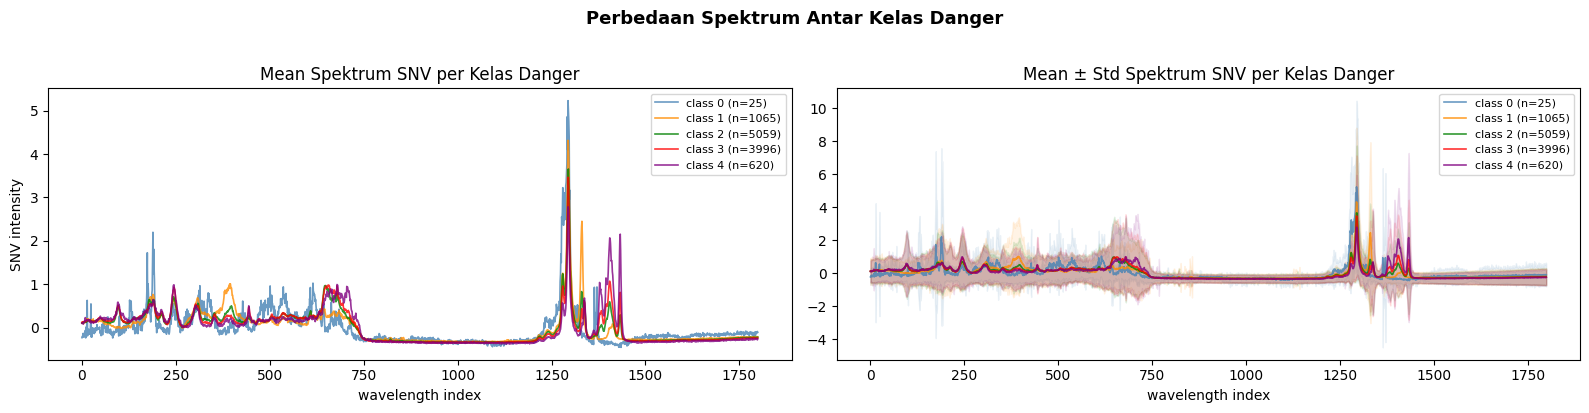

Distribusi kelas danger:
   n_samples   pct
0         25   0.2
1       1065   9.9
2       5059  47.0
3       3996  37.1
4        620   5.8


In [98]:
# Kita pilih target dengan rentang paling lebar sebagai proxy "level danger"
t_proxy = int(np.argmax(y_max))          # otomatis pilih target dengan max terbesar
RISK_BINS = [-1e9, 0.5, 1.5, 2.5, 3.5, 1e9]

y_class = np.asarray(pd.cut(y_all[:, t_proxy], bins=RISK_BINS, labels=False), np.int32)

colors = ["steelblue", "darkorange", "green", "red", "purple"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for k in range(5):
    mask = (y_class == k)
    if mask.sum() == 0:
        continue
    mean_k = X_tr_snv[mask].mean(axis=0)
    std_k  = X_tr_snv[mask].std(axis=0)
    label  = f"class {k} (n={mask.sum()})"

    axes[0].plot(wavelength, mean_k, color=colors[k], linewidth=1.2, alpha=0.8, label=label)
    axes[1].plot(wavelength, mean_k, color=colors[k], linewidth=1.2, alpha=0.8, label=label)
    axes[1].fill_between(wavelength, mean_k - std_k, mean_k + std_k, alpha=0.1, color=colors[k])

axes[0].set_title("Mean Spektrum SNV per Kelas Danger")
axes[0].set_xlabel("wavelength index")
axes[0].set_ylabel("SNV intensity")
axes[0].legend(fontsize=8)

axes[1].set_title("Mean ± Std Spektrum SNV per Kelas Danger")
axes[1].set_xlabel("wavelength index")
axes[1].legend(fontsize=8)

plt.suptitle("Perbedaan Spektrum Antar Kelas Danger", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

class_counts = pd.Series(y_class).value_counts().sort_index()
print("Distribusi kelas danger:")
print(class_counts.to_frame("n_samples").assign(
    pct=lambda x: (x["n_samples"] / x["n_samples"].sum() * 100).round(1)
))

Plot ini menunjukkan perbandingan mean spektrum SNV untuk tiap kelas danger_4 yang dibentuk dari batas 0.5, 1.5, 2.5, dan 3.5. Di panel kiri, kurva rata-rata antar kelas pada banyak rentang wavelength saling berdekatan, artinya sebagian besar area spektrum membawa pola umum yang mirip di semua kelas. Namun ada beberapa region yang lebih informatif karena kurva mulai terpisah — terutama di area awal sekitar indeks ~200, area transisi sekitar 600–700, dan paling kuat di sekitar 1.200–1.400 di mana puncak-puncak besar muncul dengan bentuk yang berbeda antar kelas. Ini memberi sinyal bahwa pemisahan kelas danger_4 lebih banyak didorong oleh perubahan bentuk dan intensitas relatif pada region spesifik, bukan oleh pergeseran global spektrum.

Panel kanan menambahkan konteks variabilitas dengan pita ±1 standar deviasi. Variansi terbesar juga terkonsentrasi di region puncak yang sama, sehingga wilayah yang paling informatif sekaligus memiliki overlap yang lebih tinggi karena noise antar sampel juga meningkat di sana. Sinyal pemisah kelas ada, tetapi berada di wilayah yang juga paling berisik — ini menjadi salah satu alasan mengapa danger_4 lebih sulit diprediksi dibanding target lain dan mengapa pendekatan yang menekankan pola terstruktur lebih relevan untuk target ini.

Distribusi kelas mengonfirmasi adanya ketidakseimbangan yang cukup ekstrem. Kelas 0 hanya berjumlah 25 sampel (~0.2%) sehingga kurva rata-ratanya pada panel kiri sangat rentan terhadap outlier dan kurang representatif. Kelas 1 sekitar 1.065 sampel (9.9%), kelas 2 sekitar 5.059 sampel (47%), kelas 3 sekitar 3.996 sampel (37.1%), dan kelas 4 sekitar 620 sampel (5.8%). Dominasi kelas 2 dan 3 membuat pola yang terlihat di plot terutama merefleksikan dua kelas ini, sementara kelas 0 dan kelas 4 memiliki dukungan data yang jauh lebih kecil.

Dua temuan ini — adanya region wavelength yang memisahkan kelas dan ketidakseimbangan kelas yang tajam — secara bersama-sama menjelaskan mengapa danger_4 wajar diperlakukan sebagai target bertingkat dengan penanganan khusus, dan mengapa evaluasi perlu mempertimbangkan performa per kelas agar sinyal dari kelas minor tidak tenggelam di balik dominasi kelas mayoritas.

### E. Region Wavelength yang Paling Diskriminatif

Dari visualisasi sebelumnya sudah terlihat bahwa perbedaan antar kelas danger_4 terkonsentrasi di wilayah wavelength tertentu. Untuk mengidentifikasi wilayah tersebut secara lebih kuantitatif, kita menghitung dua metrik per wavelength: F-statistic ANOVA yang mengukur seberapa besar perbedaan antar kelas relatif terhadap variasi di dalam kelas, dan between-class variance yang mengukur seberapa jauh mean tiap kelas menyimpang dari mean global. Wavelength dengan nilai tinggi di kedua metrik ini adalah kandidat region yang paling diskriminatif. Sebagai pelengkap, difference plot antara kelas 4 dan kelas 1 ditambahkan untuk melihat arah dan besaran perbedaan secara lebih eksplisit.

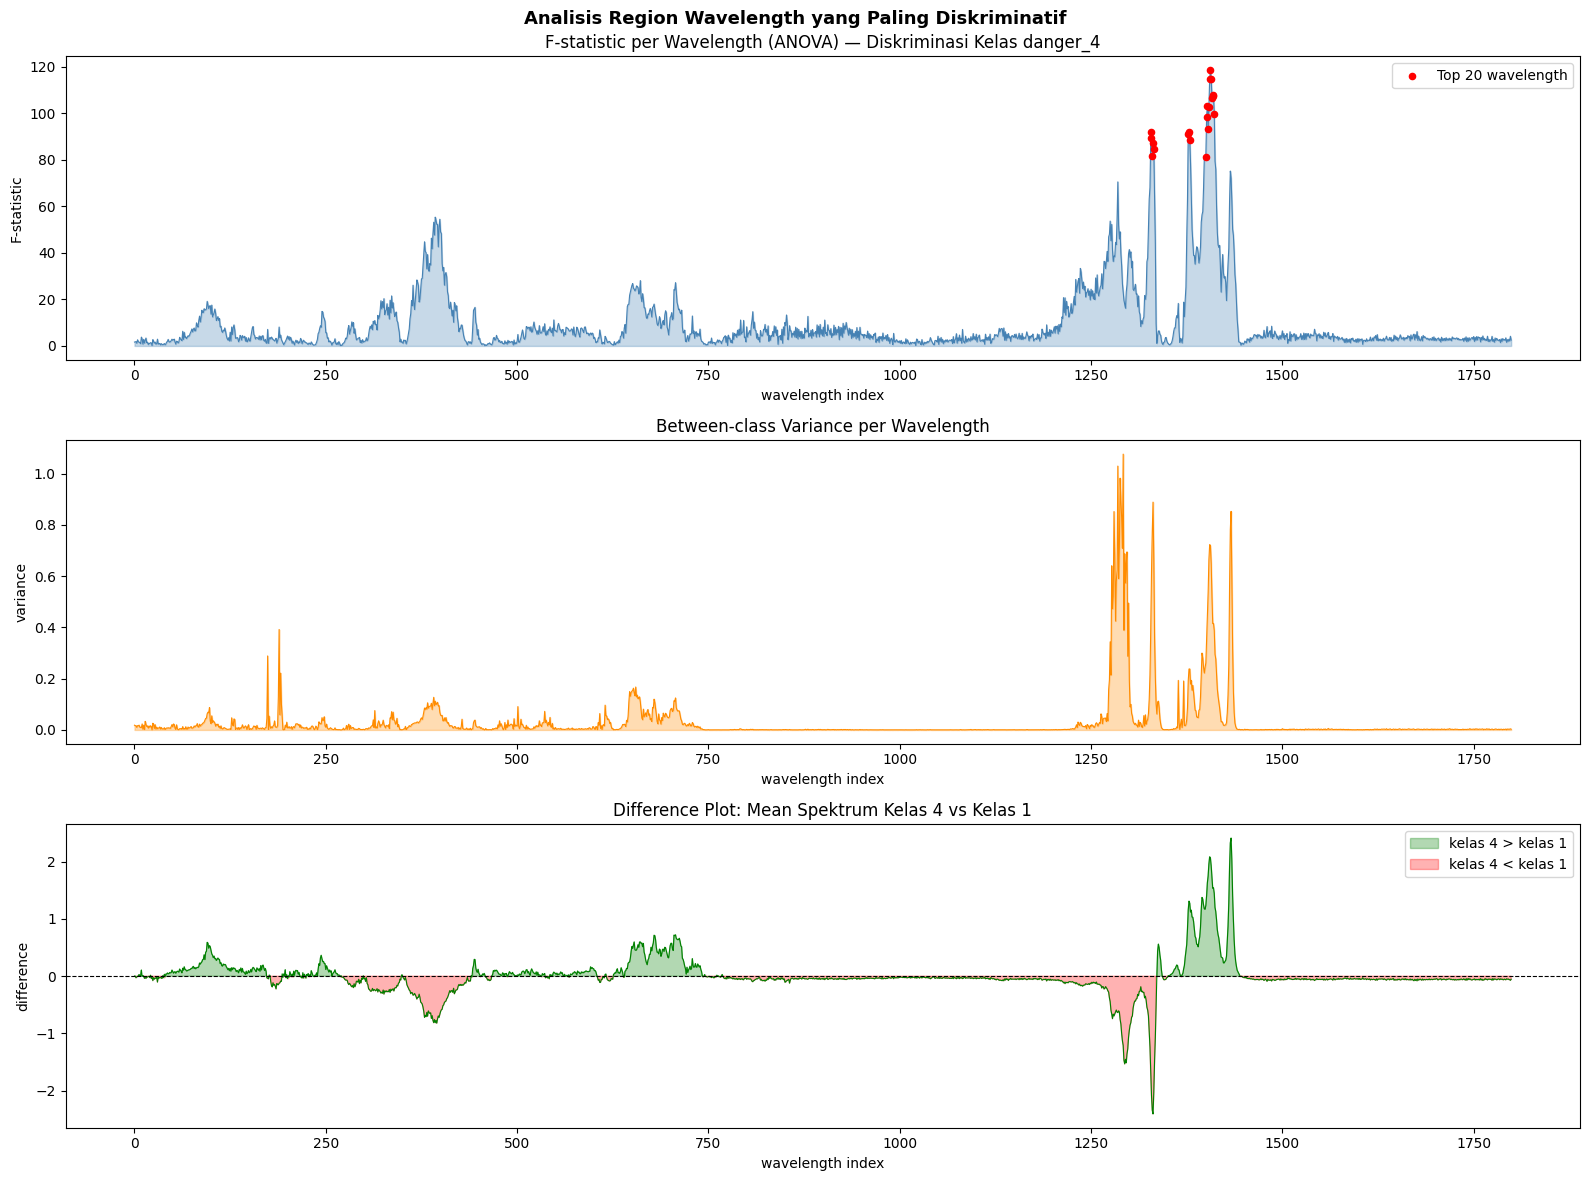

Top 10 wavelength paling diskriminatif (F-statistic):


,wavelength_idx,f_statistic,between_var
0,1406,118.62,0.719377
1,1407,114.84,0.648105
2,1405,114.83,0.723283
3,1409,108.06,0.415408
4,1410,107.49,0.415663
5,1408,106.77,0.520249
6,1402,103.19,0.454734
7,1404,102.91,0.663754
8,1411,99.84,0.387908
9,1401,98.61,0.353899


In [99]:
# Between-class variance per wavelength
D4_BINS = [-1e9, 0.5, 1.5, 2.5, 3.5, 1e9]
y4_class = np.asarray(pd.cut(y_all[:, D4], bins=D4_BINS, labels=False), np.int32)
class_means = np.array([X_tr_snv[y4_class == k].mean(axis=0) for k in range(5)])
global_mean = X_tr_snv.mean(axis=0)

# F-statistic per wavelength (ANOVA)
f_stats = np.array([
    f_oneway(*[X_tr_snv[y4_class == k, i] for k in range(5)]).statistic
    for i in range(X_tr_snv.shape[1])
])
f_stats = np.nan_to_num(f_stats, nan=0.0)

# Between-class variance
between_var = np.var(class_means, axis=0)

# Top 20 most discriminative regions
top_idx = np.argsort(f_stats)[::-1][:20]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1, F-statistic per wavelength
axes[0].plot(wavelength, f_stats, color="steelblue", linewidth=0.8)
axes[0].fill_between(wavelength, 0, f_stats, alpha=0.3, color="steelblue")
axes[0].scatter(top_idx, f_stats[top_idx], color="red", s=20, zorder=5,
                label=f"Top 20 wavelength")
axes[0].set_title("F-statistic per Wavelength (ANOVA) — Diskriminasi Kelas danger_4")
axes[0].set_xlabel("wavelength index")
axes[0].set_ylabel("F-statistic")
axes[0].legend()

# Panel 2, Between-class variance
axes[1].plot(wavelength, between_var, color="darkorange", linewidth=0.8)
axes[1].fill_between(wavelength, 0, between_var, alpha=0.3, color="darkorange")
axes[1].set_title("Between-class Variance per Wavelength")
axes[1].set_xlabel("wavelength index")
axes[1].set_ylabel("variance")

# Panel 3, Difference plot (kelas 4 vs kelas 0)
mean_high = class_means[4]
mean_low  = class_means[1]   # kelas 1 lebih stabil dari kelas 0 (n=25)
diff      = mean_high - mean_low

axes[2].plot(wavelength, diff, color="green", linewidth=0.8)
axes[2].fill_between(wavelength, 0, diff,
                     where=diff > 0, alpha=0.3, color="green",  label="kelas 4 > kelas 1")
axes[2].fill_between(wavelength, 0, diff,
                     where=diff < 0, alpha=0.3, color="red",    label="kelas 4 < kelas 1")
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Difference Plot: Mean Spektrum Kelas 4 vs Kelas 1")
axes[2].set_xlabel("wavelength index")
axes[2].set_ylabel("difference")
axes[2].legend()

plt.suptitle("Analisis Region Wavelength yang Paling Diskriminatif",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top 10 wavelength paling diskriminatif
print("Top 10 wavelength paling diskriminatif (F-statistic):")
top10 = pd.DataFrame({
    "wavelength_idx": top_idx[:10],
    "f_statistic"   : f_stats[top_idx[:10]].round(2),
    "between_var"   : between_var[top_idx[:10]].round(6),
}).reset_index(drop=True)
display(top10)

Ketiga panel secara konsisten menunjukkan temuan yang sama. F-statistic dan between-class variance sama-sama memperlihatkan bahwa sebagian besar wavelength memiliki nilai mendekati nol, sementara terdapat beberapa puncak yang sangat menonjol. Puncak tertinggi terkonsentrasi di sekitar indeks 1.300–1.450, dengan F-statistic mencapai lebih dari 100 dan between-class variance mendekati 1.0. Ada juga puncak-puncak sekunder yang lebih kecil di sekitar indeks 0–250 dan 300–700, menunjukkan bahwa wilayah tersebut juga membawa informasi diskriminatif meskipun jauh lebih lemah.

Difference plot menambahkan dimensi arah perbedaan. Di sekitar indeks 1.300, kelas 1 memiliki intensitas lebih tinggi dari kelas 4 (area merah, selisih hingga -2.5), sementara di sekitar indeks 1.350–1.400, kelas 4 yang lebih tinggi (area hijau, selisih hingga +2.5). Ini menunjukkan bahwa perbedaan antar kelas bukan sekadar soal amplitudo global, tapi soal pergeseran relatif bentuk puncak di wilayah tersebut.

Dari tabel top 10 wavelength paling diskriminatif, semua masuk di rentang indeks 1.401–1.411 dengan F-statistic antara 98 hingga 119. Temuan ini secara langsung menjadi motivasi untuk eksperimen derivative features di bagian Feature Engineering — turunan spektrum di wilayah ini diharapkan bisa mengekstrak pola pergeseran bentuk puncak yang tidak tertangkap oleh nilai raw maupun SNV.

## Kesimpulan EDA

Secara kualitas data, dataset training berisi 10.765 sampel dengan 1.800 fitur spektrum dan 5 target, sementara test berisi 2.153 sampel dengan struktur fitur yang sama. Kolom spektrum sudah dipastikan identik dan berurutan di train dan test, dan tidak ditemukan nilai null sehingga data siap dipakai tanpa imputasi. Nilai spektrum berada pada orde kecil dan sebagian negatif, ini masih wajar untuk spektrum IR yang sudah melalui preprocessing instrumen. 

Dari sisi target, kelima target tidak benar benar kontinu. Histogram dan statistik deskriptif menunjukkan puncak tajam di level tertentu, dengan perilaku yang berbeda antar target. Danger_2 sangat zero inflated dengan porsi nol sekitar seperempat data, sedangkan danger_4 sangat bertingkat dan hampir tidak punya nol, plus distribusi kelasnya timpang dengan dominasi kelas 2 dan 3. Temuan ini mengarah ke kesimpulan bahwa perlakuan seragam untuk semua target tidak optimal, dan masuk akal jika modelling dan post-processing dibuat spesifik per target. 

Hubungan antar target juga tidak terlihat seperti hubungan kontinu yang halus. Scatter matrix membentuk pola kisi garis vertikal dan horizontal yang konsisten dengan target bertingkat, dan danger_2 tampak paling menyimpang karena massa nol membentuk garis padat di banyak pasangan. Ini menyiratkan bahwa sinyal antar target lebih berupa kombinasi level daripada korelasi linear sederhana. 

Pada fitur spektrum, variasi utama tidak tersebar merata sepanjang wavelength. Spektrum raw menunjukkan spike besar dan variansi tinggi terutama di sekitar indeks 1.200 sampai 1.300, sehingga normalisasi per sampel seperti SNV relevan untuk meredam perbedaan baseline dan skala. Setelah SNV, amplitudo global antar sampel jauh lebih sejajar namun puncak kuat di sekitar indeks 1.300 tetap menonjol, menandakan ada sinyal komposisi yang nyata, bukan sekadar artefak skala. Heatmap memperlihatkan pola yang konsisten di seluruh dataset, dengan garis vertikal yang sangat jelas di sekitar indeks 1.300 dan 1.400, dan hampir tidak ada outlier ekstrem, sehingga data cukup homogen dan variasinya lebih kuantitatif daripada kualitatif. 

Ketika dianalisis per kelas pada danger_4, perbedaan spektrum antar kelas paling kuat muncul di region spesifik, terutama rentang 1.200 sampai 1.400, dan region yang paling diskriminatif terkonsentrasi di sekitar indeks 1.401 sampai 1.411 dengan F statistic sangat tinggi. Difference plot juga menunjukkan perbedaan bentuk puncak di sekitar 1.300 dan 1.350 sampai 1.400, jadi pemisahan kelas bukan hanya amplitudo global, melainkan pergeseran relatif bentuk puncak. Ini memotivasi penggunaan fitur turunan seperti Savitzky Golay, yang memang membuat perubahan bentuk di area 1.200 sampai 1.400 makin terlihat dan memberi indikasi pemisahan pola antar kelas, meski area awal wavelength cenderung lebih noisy sehingga parameternya perlu hati hati.

# Feature Engginering
Bagian ini disusun berdasarkan temuan dari Exploratory Data Analysis (EDA) yang menunjukkan bahwa informasi untuk membedakan level bahaya tidak tersebar secara merata di seluruh spektrum. Sebaliknya, informasi tersebut terpusat pada wilayah spektral tertentu dan bermanifestasi sebagai perbedaan bentuk puncak serta perubahan kurva, alih-alih sekadar pergeseran skala secara global. Oleh karena itu, tahapan rekayasa fitur (feature engineering) difokuskan pada dua sasaran utama. Pertama, menstabilkan spektrum antar-sampel guna meminimalkan bias model terhadap perbedaan baseline dan amplitudo. Kedua, mempertegas pola lokal yang relevan pada wilayah yang informatif agar sinyal pemisah antar-kelas lebih mudah diekstraksi oleh model.

Strategi prapemrosesan yang diterapkan bersifat sederhana namun terbukti efektif untuk data spektrum. Transformasi pertama yang digunakan adalah Standard Normal Variate (SNV). Metode ini berfungsi sebagai normalisasi pada tingkat sampel untuk mereduksi efek baseline dan skala, sehingga variansi yang tersisa lebih merepresentasikan bentuk relatif dari spektrum. Transformasi kedua melibatkan turunan (derivative) Savitzky-Golay untuk mengekstrak informasi terkait perubahan kemiringan (slope) dan kelengkungan kurva, yang umumnya berkorelasi dengan pergeseran puncak serapan. Kedua metode transformasi ini akan dibandingkan secara sistematis, meliputi: data dasar (baseline) tanpa transformasi, baseline dengan penambahan SNV, baseline dengan turunan Savitzky-Golay, serta kombinasi keduanya apabila diperlukan. Evaluasi dilakukan menggunakan skema validasi silang (cross-validation) yang seragam guna memastikan perbandingan yang objektif.

Pada akhir bagian ini, akan ditarik kesimpulan mengenai metode transformasi yang paling konsisten dalam meningkatkan performa pada setiap target, serta metode yang secara spesifik optimal untuk target tertentu. Hasil evaluasi ini akan menjadi landasan sebelum dilanjutkan ke tahap pemodelan (modelling) dan perancangan strategi pasca-pemrosesan (post-processing) untuk masing-masing target.

## 1. SNV
Dari plot spektrum raw, terlihat sinyal tidak seragam sepanjang wavelength dan ada region yang jauh lebih bervariasi, khususnya lonjakan besar di sekitar indeks 1.200 sampai 1.300. Kondisi ini membuat normalisasi per sampel seperti SNV masuk akal, karena kita ingin meredam perbedaan baseline dan skala antar sampel supaya model fokus ke bentuk relatif spektrum. SNV menormalisasi setiap sampel secara independen dengan mengurangkan mean dan membagi dengan standar deviasi per baris. Hasilnya, amplitudo global antar sampel lebih sejajar dan pola bentuk lebih jelas dibanding intensitas absolut. 

In [100]:
def snv_transform(X, eps=1e-12):
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / (std + eps)

X_tr_snv = snv_transform(X_tr)
X_te_snv = snv_transform(X_te)

##  2. Savitzky-Golay Derivative
Setelah SNV, langkah berikutnya adalah menguji apakah informasi bentuk spektrum bisa dibuat lebih eksplisit dengan menghitung turunan pertama dan kedua sepanjang dimensi wavelength. Turunan pertama menonjolkan perubahan slope, turunan kedua menonjolkan puncak dan lembah tajam, sehingga pergeseran bentuk puncak di region informatif lebih mudah terlihat. Implementasi memakai savgol_filter dan mengembalikan dua matriks fitur baru untuk seluruh sampel, dengan parameter utama panjang jendela dan orde polinomial. 

In [101]:
def apply_savgol_derivative(X, window_length=11, polyorder=2):
    X_d1 = savgol_filter(X, window_length=window_length,
                         polyorder=polyorder, deriv=1, axis=1).astype(np.float32)
    X_d2 = savgol_filter(X, window_length=window_length,
                         polyorder=polyorder, deriv=2, axis=1).astype(np.float32)
    return X_d1, X_d2

X_d1_tr, X_d2_tr = apply_savgol_derivative(X_tr_snv, window_length=11, polyorder=2)
X_d1_te, X_d2_te = apply_savgol_derivative(X_te_snv, window_length=11, polyorder=2)

Dari visualisasi awal, aktivitas turunan paling kuat memang muncul di rentang yang sebelumnya terlihat kaya sinyal, terutama sekitar 1.200 sampai 1.400. Ini memberi indikasi bahwa derivative features berpotensi menambah daya pisah. Namun area awal wavelength masih cenderung lebih noisy, jadi pemilihan window_length dan polyorder perlu hati hati supaya turunan tidak memperbesar fluktuasi yang tidak relevan.

## 3. Visualisasi Feature Engginering
Visualisasi pada bagian ini tidak dimaksudkan sebagai eksplorasi ulang seperti EDA, tetapi sebagai sanity check bahwa transformasi yang diterapkan benar benar melakukan hal yang diinginkan. Untuk SNV, overlay spektrum sebelum dan sesudah transformasi digunakan untuk menunjukkan bahwa variasi baseline dan skala antar sampel mengecil. Untuk Savitzky Golay derivative, overlay dan ringkasan rata rata dipakai untuk memperlihatkan bahwa informasi perubahan bentuk seperti slope dan puncak menjadi lebih eksplisit pada region informatif. Visualisasi ini menjadi dasar intuisi, sedangkan keputusan akhir pemakaian transformasi tetap diambil dari hasil validasi cross validation dan studi ablasi pada tahap berikutnya.

### A. Raw vs SNV

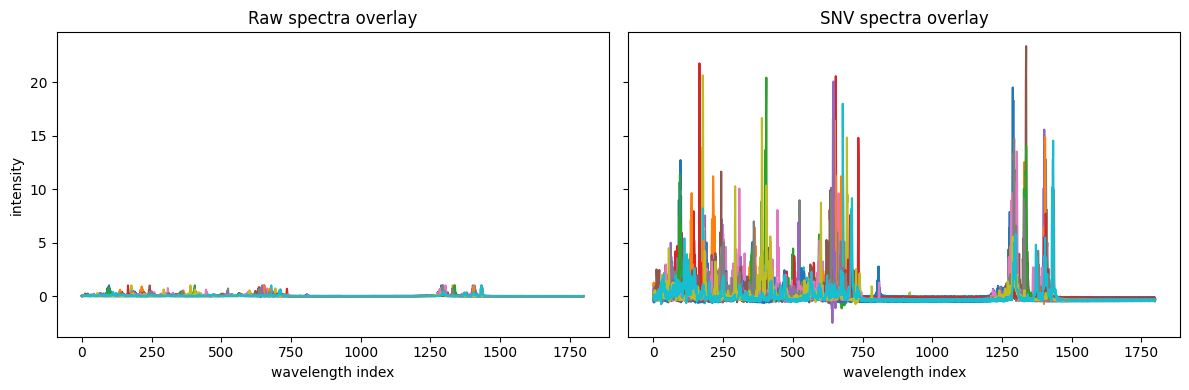

In [102]:
RNG = np.random.default_rng(42)

def pick_samples(n, total):
    n = min(n, total)
    return RNG.choice(total, size=n, replace=False)

def plot_overlays_row(X_list, titles, idxs, x_axis=None, figsize_per_plot=6):
    k = len(X_list)
    fig, axes = plt.subplots(1, k, figsize=(figsize_per_plot * k, 4), sharey=True)

    if k == 1:
        axes = [axes]

    for ax, X, title in zip(axes, X_list, titles):
        for i in idxs:
            if x_axis is None:
                ax.plot(X[i])
            else:
                ax.plot(x_axis, X[i])
        ax.set_title(title)
        ax.set_xlabel("wavelength index" if x_axis is None else "wavelength")

    axes[0].set_ylabel("intensity")
    plt.tight_layout()
    plt.show()

plot_overlays_row(
    [X_tr, X_tr_snv],
    ["Raw spectra overlay", "SNV spectra overlay"],
    idxs
)

### B. histogram mean dan std per sampel

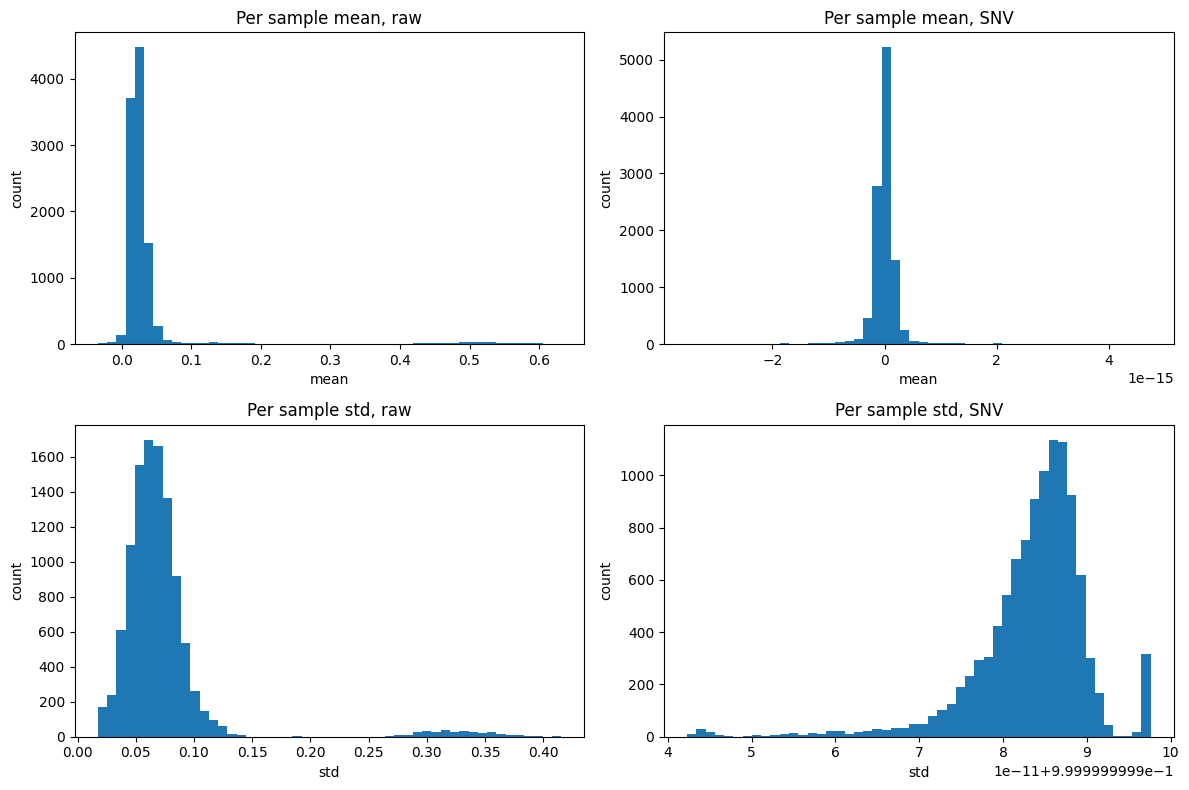

In [103]:
raw_mean = X_tr.mean(axis=1)
raw_std  = X_tr.std(axis=1)

snv_mean = X_tr_snv.mean(axis=1)
snv_std  = X_tr_snv.std(axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(raw_mean, bins=50)
axes[0, 0].set_title("Per sample mean, raw")
axes[0, 0].set_xlabel("mean")
axes[0, 0].set_ylabel("count")

axes[0, 1].hist(snv_mean, bins=50)
axes[0, 1].set_title("Per sample mean, SNV")
axes[0, 1].set_xlabel("mean")
axes[0, 1].set_ylabel("count")

axes[1, 0].hist(raw_std, bins=50)
axes[1, 0].set_title("Per sample std, raw")
axes[1, 0].set_xlabel("std")
axes[1, 0].set_ylabel("count")

axes[1, 1].hist(snv_std, bins=50)
axes[1, 1].set_title("Per sample std, SNV")
axes[1, 1].set_xlabel("std")
axes[1, 1].set_ylabel("count")

plt.tight_layout()
plt.show()

### C. Visualisasi per Kelas

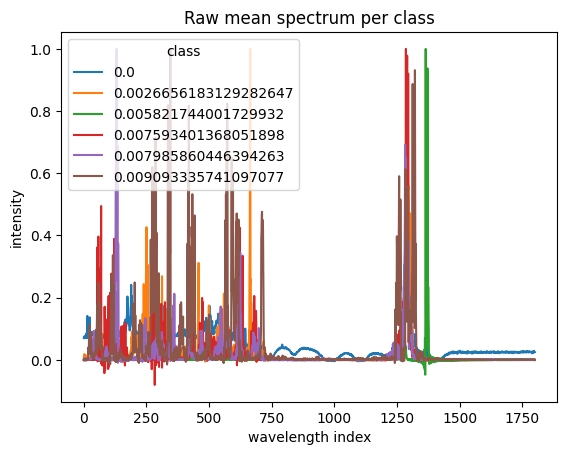

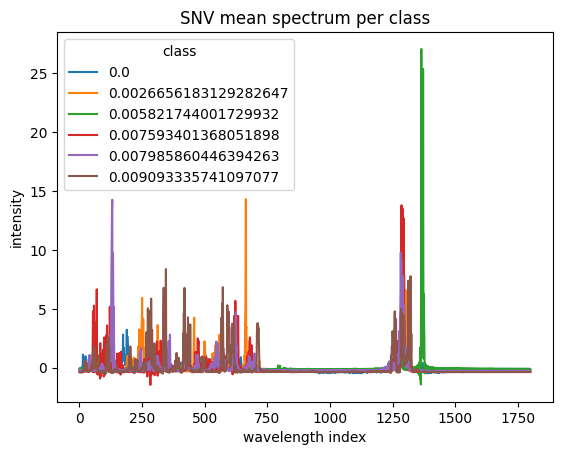

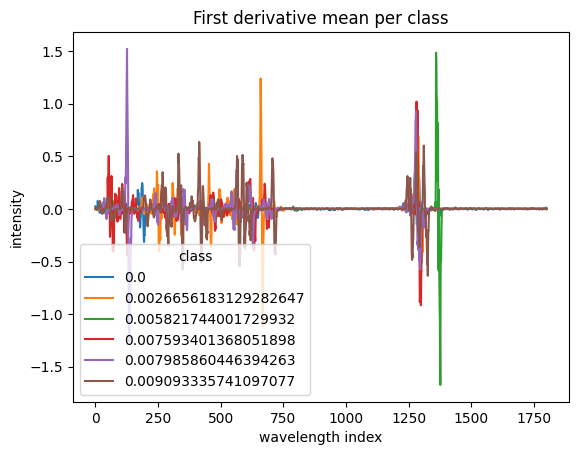

In [104]:
def plot_mean_by_class(X, y, title, max_classes=6):
    plt.figure()
    classes = np.unique(y)
    classes = classes[:max_classes]
    for c in classes:
        m = X[y == c].mean(axis=0)
        plt.plot(m, label=str(c))
    plt.title(title)
    plt.xlabel("wavelength index")
    plt.ylabel("intensity")
    plt.legend(title="class")
    plt.show()

target_cols = ["danger_1", "danger_2", "danger_3", "danger_4", "danger_5"]

y_train = train[target_cols].copy()

y_target = y_train["danger_4"].values
plot_mean_by_class(X_tr, y_target, "Raw mean spectrum per class")
plot_mean_by_class(X_tr_snv, y_target, "SNV mean spectrum per class")
plot_mean_by_class(X_d1_tr, y_target, "First derivative mean per class")

## Kesimpulan Feature Engineering

Rekayasa fitur difokuskan pada dua hal, menstabilkan spektrum antar sampel dan menonjolkan pola lokal yang relevan di region informatif. SNV terbukti efektif mengurangi efek baseline dan skala sehingga pola bentuk spektrum lebih jelas, lalu dipakai sebagai default preprocessing untuk sebagian besar target, sementara danger_3 dipertahankan menggunakan raw karena validasi lebih baik tanpa transformasi. Setelah itu, Savitzky Golay derivative diuji untuk membuat perubahan slope dan puncak lebih eksplisit, terutama di rentang 1.200 sampai 1.400 yang sebelumnya terlihat kaya sinyal, dengan catatan area awal wavelength lebih noisy sehingga parameter perlu dipilih hati hati. Visualisasi pada bagian ini berperan sebagai sanity check bahwa transformasi bekerja sesuai tujuan, sedangkan keputusan akhir pemakaian transformasi ditentukan oleh hasil cross validation dan studi ablasi pada tahap berikutnya

# Modeling
Tahap pemodelan pada penelitian ini dirancang sebagai serangkaian eksperimen terkontrol yang bermuara pada satu pipeline akhir yang bersifat reproducible. Tujuan utamanya bukan sekadar mencapai nilai Mean Absolute Error (MAE) yang rendah, melainkan juga untuk membangun sistem yang stabil saat dijalankan ulang, serta memiliki konsistensi performa antara evaluasi Out-of-Fold (OOF) dan inferensi pada data uji.

Pipeline akhir terdiri dari dua komponen utama. Komponen pertama adalah model utama berbasis regresi LightGBM dengan fungsi objektif L1 untuk menghasilkan prediksi kontinu. Komponen kedua adalah tahap post-processing snap untuk setiap target, yang berfungsi memetakan hasil prediksi kontinu ke dalam bentuk diskrit yang lebih selaras dengan struktur label asli pada data. Guna memastikan bahwa setiap keputusan arsitektur didasarkan pada landasan empiris dan bukan sekadar asumsi, tahapan pemodelan dilakukan melalui studi eksperimental bertahap berikut.

Metrik performa yang digunakan adalah MAE untuk masing-masing target, yang kemudian dirata-ratakan sebagai skor akhir keseluruhan. Seluruh keputusan desain dan pemilihan parameter secara eksklusif didasarkan pada skor prediksi OOF, bukan skor latih, guna menghindari bias dan indikasi overfitting.

Mengingat target prediksi memiliki sifat kontinu maupun semi-diskrit, pembagian fold atau stratifikasi tidak dapat dilakukan secara langsung menggunakan label mentah. Solusi yang diterapkan adalah membuat label stratifikasi dari target menggunakan metode binning. Target Kontinu, Stratifikasi dilakukan menggunakan quantile binning sehingga setiap fold memiliki distribusi nilai yang serupa.Target Bertingkat, Stratifikasi dibentuk melalui pemotongan level menggunakan cut bins agar representasi setiap tingkatan kelas tetap terjaga di setiap fold.Pendekatan ini secara praktis bertujuan untuk memperkecil variansi skor OOF, sehingga perbandingan performa antar-eksperimen menjadi lebih berimbang dan objektif.<br>

Untuk menjaga stabilitas sistem, seluruh proses eksperimen menggunakan fixed seed, dan algoritma LightGBM dikonfigurasi agar berjalan se-deterministik mungkin sesuai dengan batasan komputasi. Mengingat banyaknya iterasi eksperimen yang harus dieksekusi ulang, pipeline final menggunakan known best iterations. Hal ini dilakukan untuk menghindari ketergantungan pada mekanisme early stopping yang dapat menghasilkan jumlah pohon berbeda pada setiap eksekusi.

## Eksperimen 1 Baseline LightGBM + Raw vs SNV
Eksperimen ini menguji baseline LightGBM regresi L1 pada fitur spektrum. Dua varian input dibandingkan secara terkontrol, raw dan SNV. Evaluasi menggunakan prediksi out of fold dengan StratifiedKFold berbasis binning target agar distribusi target di tiap fold lebih seimbang. Hasil eksperimen berupa MAE per target dan selisih performa raw dibanding SNV.

**Utilities**

Karena target bersifat kontinu atau semi diskrit, StratifiedKFold membutuhkan label stratifikasi buatan. Fungsi berikut membuat bin berbasis quantile supaya distribusi target di tiap fold lebih seimbang dan evaluasi OOF lebih stabil.

In [105]:
def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

def clip_pred(pred: np.ndarray, y_min: float, y_max: float) -> np.ndarray:
    return np.clip(pred, y_min, y_max).astype(np.float32)

def make_quantile_bins(y: np.ndarray, n_bins: int = 20) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32)
    r = pd.Series(y).rank(method="first")
    b = pd.qcut(r, q=n_bins, labels=False, duplicates="drop")
    return np.asarray(b, dtype=np.int32)

def snv_transform(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd).astype(np.float32)
    return ((X - mu) / sd).astype(np.float32)

# baseline params untuk eksperimen 1
def get_params(t: int, seed: int = 42) -> dict:
    return dict(
        objective="regression_l1",
        metric="l1",
        learning_rate=0.05,
        n_estimators=2000,
        num_leaves=63,
        max_depth=-1,
        min_data_in_leaf=100,
        feature_fraction=0.85,
        bagging_fraction=0.85,
        bagging_freq=1,
        reg_lambda=1.0,
        max_bin=255,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
        force_col_wise=True
    )

In [106]:
# Prepare Data

CFG = dict(
    n_splits=3,
    early_stopping_rounds=100,
    log_period=1000, 
)

spec_cols = [c for c in train.columns if c.startswith("spec_")]
X_raw = train[spec_cols].to_numpy(dtype=np.float32)

y = train[TARGET_COLS].to_numpy(dtype=np.float32)
y_min = y.min(axis=0).astype(np.float32)
y_max = y.max(axis=0).astype(np.float32)

X_snv = snv_transform(X_raw)

print("X_raw:", X_raw.shape, "X_snv:", X_snv.shape, "y:", y.shape)

X_raw: (10765, 1800) X_snv: (10765, 1800) y: (10765, 5)


In [107]:
def run_oof_lgb_baseline(
    t: int,
    X: np.ndarray,
    y_t: np.ndarray,
    y_min_t: float,
    y_max_t: float,
    n_splits: int = 2,
    seed: int = 42,
    n_bins: int = 20,
    early_stopping_rounds: int = 200,
    log_period: int | None = 200,
):
    y_t = np.asarray(y_t, dtype=np.float32)
    bins = make_quantile_bins(y_t, n_bins=n_bins)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    oof = np.zeros_like(y_t, dtype=np.float32)
    fold_mae = []
    fold_best_iter = []

    params = dict(get_params(t))
    params["random_state"] = seed

    callbacks = [lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False)]
    if log_period is not None:
        callbacks.append(lgb.log_evaluation(period=int(log_period)))

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, bins), start=1):
        m = lgb.LGBMRegressor(**params)
        m.fit(
            X[tr_idx], y_t[tr_idx],
            eval_set=[(X[va_idx], y_t[va_idx])],
            eval_metric="l1",
            callbacks=callbacks
        )

        best_iter = int(getattr(m, "best_iteration_", params.get("n_estimators", 0)) or params.get("n_estimators", 0))
        pv = m.predict(X[va_idx], num_iteration=best_iter).astype(np.float32)
        pv = clip_pred(pv, float(y_min_t), float(y_max_t))

        oof[va_idx] = pv

        mae = float(mean_absolute_error(y_t[va_idx], pv))
        fold_mae.append(mae)
        fold_best_iter.append(best_iter)

        print(f"{TARGET_COLS[t]} | fold {fold} | MAE {mae:.6f} | best_iter {best_iter}")

    oof_mae = float(mean_absolute_error(y_t, oof))
    print(f"{TARGET_COLS[t]} | OOF MAE {oof_mae:.6f}")

    return {
        "oof": oof,
        "oof_mae": oof_mae,
        "fold_mae": fold_mae,
        "fold_best_iter": fold_best_iter
    }

In [108]:
exp1_rows = []
exp1_artifacts = {
    "raw": {},
    "snv": {}
}

for t in range(len(TARGET_COLS)):
    y_t = y[:, t]
    y_min_t = float(y_min[t])
    y_max_t = float(y_max[t])

    print("\n" + "=" * 60)
    print("EXPERIMENT 1 | RAW |", TARGET_COLS[t])
    out_raw = run_oof_lgb_baseline(
        t=t, X=X_raw, y_t=y_t, y_min_t=y_min_t, y_max_t=y_max_t,
        n_splits=CFG["n_splits"],
        seed=SEED,
        n_bins=20,
        early_stopping_rounds=CFG["early_stopping_rounds"],
        log_period=CFG["log_period"],
    )
    exp1_artifacts["raw"][t] = out_raw

    print("\n" + "-" * 60)
    print("EXPERIMENT 1 | SNV |", TARGET_COLS[t])
    out_snv = run_oof_lgb_baseline(
        t=t, X=X_snv, y_t=y_t, y_min_t=y_min_t, y_max_t=y_max_t,
        n_splits=CFG["n_splits"],
        seed=SEED,
        n_bins=20,
        early_stopping_rounds=CFG["early_stopping_rounds"],
        log_period=CFG["log_period"],
    )
    exp1_artifacts["snv"][t] = out_snv

    mae_raw = out_raw["oof_mae"]
    mae_snv = out_snv["oof_mae"]
    delta = mae_snv - mae_raw
    pick = "SNV" if mae_snv < mae_raw else "RAW"

    exp1_rows.append({
        "target": TARGET_COLS[t],
        "mae_raw": mae_raw,
        "mae_snv": mae_snv,
        "delta_snv_minus_raw": delta,
        "pick_input": pick,
        "best_iter_raw_median": int(np.median(out_raw["fold_best_iter"])),
        "best_iter_snv_median": int(np.median(out_snv["fold_best_iter"])),
    })

exp1_df = pd.DataFrame(exp1_rows)
exp1_df


EXPERIMENT 1 | RAW | danger_1
[1000]	valid_0's l1: 0.194131
[2000]	valid_0's l1: 0.193702
danger_1 | fold 1 | MAE 0.193677 | best_iter 1941
[1000]	valid_0's l1: 0.196229
[2000]	valid_0's l1: 0.195835
danger_1 | fold 2 | MAE 0.195768 | best_iter 1972
[1000]	valid_0's l1: 0.196832
[2000]	valid_0's l1: 0.196339
danger_1 | fold 3 | MAE 0.196304 | best_iter 1997
danger_1 | OOF MAE 0.195249

------------------------------------------------------------
EXPERIMENT 1 | SNV | danger_1
[1000]	valid_0's l1: 0.192361
[2000]	valid_0's l1: 0.19194
danger_1 | fold 1 | MAE 0.191927 | best_iter 2000
[1000]	valid_0's l1: 0.193543
[2000]	valid_0's l1: 0.193118
danger_1 | fold 2 | MAE 0.193087 | best_iter 1965
[1000]	valid_0's l1: 0.196819
[2000]	valid_0's l1: 0.196388
danger_1 | fold 3 | MAE 0.196382 | best_iter 1987
danger_1 | OOF MAE 0.193798

EXPERIMENT 1 | RAW | danger_2
danger_2 | fold 1 | MAE 0.166371 | best_iter 663
danger_2 | fold 2 | MAE 0.166077 | best_iter 339
danger_2 | fold 3 | MAE 0.168457 

,target,mae_raw,mae_snv,delta_snv_minus_raw,pick_input,best_iter_raw_median,best_iter_snv_median
0,danger_1,0.195249,0.193798,-0.001451,SNV,1972,1987
1,danger_2,0.166968,0.166099,-0.000869,SNV,339,370
2,danger_3,0.066981,0.064350,-0.002631,SNV,1985,1998
3,danger_4,0.512558,0.507890,-0.004668,SNV,1653,1343
4,danger_5,0.182266,0.179064,-0.003202,SNV,720,991


SNV memberikan perbaikan MAE yang konsisten pada seluruh target dibandingkan spektrum raw. Peningkatan paling besar terlihat pada danger_4 dan danger_5, sementara target lain juga menunjukkan penurunan error meski lebih kecil. Karena tren perbaikan terjadi pada semua target, eksperimen selanjutnya menggunakan input SNV sebagai default agar perbandingan antar eksperimen lebih fokus pada perubahan parameter model dan post-processing, bukan perbedaan preprocessing.

In [9]:
FORCE_ALL_SNV = True

def get_X_for_target(t: int, X_raw: np.ndarray, X_snv: np.ndarray, use_exp1_pick: bool = True) -> np.ndarray:
    if FORCE_ALL_SNV:
        return X_snv
    if use_exp1_pick and "exp1_df" in globals():
        row = exp1_df.loc[exp1_df["target"] == TARGET_COLS[t]].iloc[0]
        return X_snv if row["pick_input"] == "SNV" else X_raw
    return X_raw

## Eksperimen 2 Stabilitas CV dan kapasitas model

Eksperimen ini bertujuan memilih parameter LightGBM terbaik untuk masing masing target. Karena karakter label dan tingkat kesulitan tiap target berbeda, parameter tidak dipaksa sama untuk semua target. Seleksi dilakukan berbasis MAE OOF dengan CV yang sama, dan hasil akhirnya berupa satu set parameter final per target dan jumlah boosting iteration yang dipakai pada pipeline final.

In [2]:
warnings.filterwarnings("ignore", message="X does not have valid feature names*")
warnings.filterwarnings("ignore")

# CONFIG
SEED = 42
TARGET_COLS = [f"danger_{i}" for i in range(1, 6)]
D1, D2, D3, D4, D5 = 0, 1, 2, 3, 4

STRAT_N_BINS = 20

# D4 bins untuk stratifikasi 
D4_BINS = [-1e9, 0.5, 1.5, 2.5, 3.5, 1e9]

# fallback
SNV_TARGETS = (D1, D2, D4, D5)

# UTILS
def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

def clip_pred(pred: np.ndarray, y_min: float, y_max: float) -> np.ndarray:
    return np.clip(pred, y_min, y_max).astype(np.float32)

def make_quantile_bins(y: np.ndarray, n_bins: int = 20) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32)
    r = pd.Series(y).rank(method="first")
    b = pd.qcut(r, q=n_bins, labels=False, duplicates="drop")
    return np.asarray(b, dtype=np.int32)

def snv_transform(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd).astype(np.float32)
    return ((X - mu) / sd).astype(np.float32)

def make_strat_bins(t: int, y_t: np.ndarray, n_bins: int = STRAT_N_BINS) -> np.ndarray:
    y_t = np.asarray(y_t, dtype=np.float32)
    if t == D4:
        b = pd.cut(y_t, bins=D4_BINS, labels=False).astype(np.int32)
        return np.asarray(b, dtype=np.int32)
    return make_quantile_bins(y_t, n_bins=int(n_bins))

def get_X_for_target(
    t: int,
    X_raw: np.ndarray,
    X_snv: np.ndarray,
    use_exp1_pick: bool = True
) -> np.ndarray:
    if use_exp1_pick and "exp1_df" in globals():
        row = exp1_df.loc[exp1_df["target"] == TARGET_COLS[t]].iloc[0]
        return X_snv if row["pick_input"] == "SNV" else X_raw
    return X_snv if (t in SNV_TARGETS) else X_raw

def build_folds_for_target(
    t: int,
    y_t: np.ndarray,
    n_splits: int,
    seed: int,
    strat_n_bins: int
) -> List[Tuple[np.ndarray, np.ndarray]]:
    bins = make_strat_bins(t, y_t, n_bins=strat_n_bins)
    skf = StratifiedKFold(n_splits=int(n_splits), shuffle=True, random_state=int(seed))
    return list(skf.split(np.zeros(len(y_t)), bins))

def run_oof_lgb_candidate(
    t: int,
    X: np.ndarray,
    y_t: np.ndarray,
    y_min_t: float,
    y_max_t: float,
    params: dict,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    early_stopping_rounds: int,
    log_period: Optional[int]
) -> dict:
    y_t = np.asarray(y_t, dtype=np.float32)
    oof = np.zeros_like(y_t, dtype=np.float32)
    fold_mae = []
    fold_best_iter = []
    fold_time = []

    p = dict(params)
    p["random_state"] = SEED

    callbacks = [lgb.early_stopping(stopping_rounds=int(early_stopping_rounds), verbose=False)]
    if log_period is not None:
        callbacks.append(lgb.log_evaluation(period=int(log_period)))

    for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
        t0 = time.perf_counter()

        m = lgb.LGBMRegressor(**p)
        m.fit(
            X[tr_idx], y_t[tr_idx],
            eval_set=[(X[va_idx], y_t[va_idx])],
            eval_metric="l1",
            callbacks=callbacks
        )

        dt = time.perf_counter() - t0

        best_iter = int(getattr(m, "best_iteration_", p.get("n_estimators", 0)) or p.get("n_estimators", 0))
        pv = m.predict(X[va_idx], num_iteration=best_iter).astype(np.float32)
        pv = clip_pred(pv, float(y_min_t), float(y_max_t))

        oof[va_idx] = pv

        mae = float(mean_absolute_error(y_t[va_idx], pv))
        fold_mae.append(mae)
        fold_best_iter.append(best_iter)
        fold_time.append(float(dt))

        print(f"{TARGET_COLS[t]} | fold {fold} | MAE {mae:.6f} | best_iter {best_iter} | time {dt:.2f}s")

    oof_mae = float(mean_absolute_error(y_t, oof))

    return dict(
        oof=oof,
        oof_mae=oof_mae,
        fold_mae=fold_mae,
        fold_mae_mean=float(np.mean(fold_mae)),
        fold_mae_std=float(np.std(fold_mae)),
        fold_best_iter=fold_best_iter,
        best_iter_median=int(np.median(fold_best_iter)),
        fold_time=fold_time,
        fold_time_sum=float(np.sum(fold_time)),
    )

In [18]:
# Kandidat parameter
PARAMS_D1 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.05,
    n_estimators=5000,
    num_leaves=63,
    max_depth=-1,
    min_data_in_leaf=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    reg_lambda=0.5,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_BASE = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.05,
    n_estimators=2000,
    num_leaves=63,
    max_depth=10,
    min_data_in_leaf=200,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    max_bin=127,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_D4 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.10,
    n_estimators=2000,
    num_leaves=63,
    max_depth=-1,
    min_data_in_leaf=150,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    max_bin=127,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_D5 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.02,
    n_estimators=2000,
    num_leaves=127,
    max_depth=-1,
    min_data_in_leaf=50,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    reg_lambda=0.5,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

# Kandidat grid per target
EXP2_PARAM_GRID = {
    D1: [
        {"name": "old_baseline", "params": PARAMS_BASE},
        {"name": "d1_tuned",     "params": PARAMS_D1},
    ],
    D2: [
        {"name": "old_baseline", "params": PARAMS_BASE},
    ],
    D3: [
        {"name": "old_baseline", "params": PARAMS_BASE},
    ],
    D4: [
        {"name": "old_baseline", "params": PARAMS_BASE},
        {"name": "d4_tuned",     "params": PARAMS_D4},
    ],
    D5: [
        {"name": "old_baseline", "params": PARAMS_BASE},
        {"name": "d5_tuned",     "params": PARAMS_D5},
    ],
}


In [19]:
def run_experiment_2(
    train_df: pd.DataFrame,
    run: bool = True,
    use_exp1_pick: bool = True,
    strat_n_bins: int = STRAT_N_BINS
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    seed_everything(SEED)

    spec_cols = [c for c in train_df.columns if c.startswith("spec_")]
    X_raw = train_df[spec_cols].to_numpy(dtype=np.float32)
    X_snv = snv_transform(X_raw)

    y = train_df[TARGET_COLS].to_numpy(dtype=np.float32)
    y_min = y.min(axis=0).astype(np.float32)
    y_max = y.max(axis=0).astype(np.float32)

    print("X_raw:", X_raw.shape, "X_snv:", X_snv.shape, "y:", y.shape)

    folds_map: Dict[int, List[Tuple[np.ndarray, np.ndarray]]] = {}
    for t in range(len(TARGET_COLS)):
        folds_map[t] = build_folds_for_target(
            t=t,
            y_t=y[:, t],
            n_splits=CFG["n_splits"],
            seed=SEED,
            strat_n_bins=strat_n_bins
        )

    rows = []
    best_rows = []

    for t in range(len(TARGET_COLS)):
        print("\n" + "=" * 70)
        print("EXPERIMENT 2 | PARAM SEARCH |", TARGET_COLS[t])

        X_use = get_X_for_target(t, X_raw, X_snv, use_exp1_pick=use_exp1_pick)
        input_used = "SNV" if (X_use is X_snv) else "RAW"

        best_mae = 1e9
        best_name = None
        best_iter_median = None
        best_std = None
        best_time = None

        for cand in EXP2_PARAM_GRID[t]:
            name = cand["name"]
            params = cand["params"]

            print("\n" + "-" * 70)
            print("target:", TARGET_COLS[t], "| input:", input_used, "| candidate:", name)

            out = None
            if run:
                out = run_oof_lgb_candidate(
                    t=t,
                    X=X_use,
                    y_t=y[:, t],
                    y_min_t=float(y_min[t]),
                    y_max_t=float(y_max[t]),
                    params=params,
                    folds=folds_map[t],
                    early_stopping_rounds=CFG["early_stopping_rounds"],
                    log_period=CFG["log_period"],
                )
                print(f"{TARGET_COLS[t]} | candidate {name} | OOF MAE {out['oof_mae']:.6f} | "
                      f"fold_std {out['fold_mae_std']:.6f} | best_iter_median {out['best_iter_median']}")

            rows.append({
                "target": TARGET_COLS[t],
                "input_used": input_used,
                "candidate": name,
                "oof_mae": None if out is None else out["oof_mae"],
                "fold_mae_std": None if out is None else out["fold_mae_std"],
                "best_iter_median": None if out is None else out["best_iter_median"],
                "train_time_sum_sec": None if out is None else out["fold_time_sum"],
                "learning_rate": params.get("learning_rate"),
                "n_estimators": params.get("n_estimators"),
                "num_leaves": params.get("num_leaves"),
                "max_depth": params.get("max_depth"),
                "min_data_in_leaf": params.get("min_data_in_leaf"),
                "feature_fraction": params.get("feature_fraction"),
                "bagging_fraction": params.get("bagging_fraction"),
                "reg_lambda": params.get("reg_lambda"),
                "max_bin": params.get("max_bin"),
            })

            if out is not None and out["oof_mae"] < best_mae:
                best_mae = out["oof_mae"]
                best_name = name
                best_iter_median = out["best_iter_median"]
                best_std = out["fold_mae_std"]
                best_time = out["fold_time_sum"]

        best_rows.append({
            "target": TARGET_COLS[t],
            "input_used": input_used,
            "best_candidate": best_name,
            "best_oof_mae": None if (not run) else float(best_mae),
            "best_fold_mae_std": None if (not run) else float(best_std),
            "best_iter_median": None if (not run) else int(best_iter_median) if best_iter_median is not None else None,
            "train_time_sum_sec": None if (not run) else float(best_time) if best_time is not None else None,
        })

    exp2_df = pd.DataFrame(rows)
    exp2_best = pd.DataFrame(best_rows)

    return exp2_df, exp2_best



In [20]:
RUN_EXP2 = True         
USE_EXP1_PICK = True    
STRAT_BINS = 20        

exp2_df, exp2_best = run_experiment_2(
    train_df=train,
    run=RUN_EXP2,
    use_exp1_pick=USE_EXP1_PICK,
    strat_n_bins=STRAT_BINS
)

print("\n" + "=" * 70)
print("EXPERIMENT 2 RESULTS BEST PER TARGET")
display(exp2_best)

print("\nEXPERIMENT 2 ALL CANDIDATES")
display(exp2_df.sort_values(["target", "oof_mae"]))

X_raw: (10765, 1800) X_snv: (10765, 1800) y: (10765, 5)

EXPERIMENT 2 | PARAM SEARCH | danger_1

----------------------------------------------------------------------
target: danger_1 | input: SNV | candidate: old_baseline
[1000]	valid_0's l1: 0.194026
[2000]	valid_0's l1: 0.193454
danger_1 | fold 1 | MAE 0.193431 | best_iter 1989 | time 83.84s
[1000]	valid_0's l1: 0.193643
danger_1 | fold 2 | MAE 0.193352 | best_iter 1419 | time 64.11s
[1000]	valid_0's l1: 0.196421
[2000]	valid_0's l1: 0.19584
danger_1 | fold 3 | MAE 0.195840 | best_iter 2000 | time 83.44s
danger_1 | candidate old_baseline | OOF MAE 0.194208 | fold_std 0.001155 | best_iter_median 1989

----------------------------------------------------------------------
target: danger_1 | input: SNV | candidate: d1_tuned
danger_1 | fold 1 | MAE 0.192923 | best_iter 581 | time 159.90s
[1000]	valid_0's l1: 0.193794
danger_1 | fold 2 | MAE 0.193647 | best_iter 1225 | time 299.31s
[1000]	valid_0's l1: 0.196325
danger_1 | fold 3 | MAE 0

,target,input_used,best_candidate,best_oof_mae,best_fold_mae_std,best_iter_median,train_time_sum_sec
0,danger_1,SNV,old_baseline,0.194208,0.001155,1989,231.398562
1,danger_2,SNV,old_baseline,0.163638,0.000372,665,112.908686
2,danger_3,SNV,old_baseline,0.067623,0.000467,2000,254.612668
3,danger_4,SNV,old_baseline,0.504374,0.003113,996,162.423201
4,danger_5,SNV,d5_tuned,0.177368,0.000801,792,723.021722



EXPERIMENT 2 ALL CANDIDATES


,target,input_used,candidate,oof_mae,fold_mae_std,best_iter_median,train_time_sum_sec,learning_rate,n_estimators,num_leaves,max_depth,min_data_in_leaf,feature_fraction,bagging_fraction,reg_lambda,max_bin
0,danger_1,SNV,old_baseline,0.194208,0.001155,1989,231.398562,0.05,2000,63,10,200,0.80,0.80,1.0,127
1,danger_1,SNV,d1_tuned,0.194234,0.001374,1225,780.844780,0.05,5000,63,-1,50,0.90,0.90,0.5,255
2,danger_2,SNV,old_baseline,0.163638,0.000372,665,112.908686,0.05,2000,63,10,200,0.80,0.80,1.0,127
3,danger_3,SNV,old_baseline,0.067623,0.000467,2000,254.612668,0.05,2000,63,10,200,0.80,0.80,1.0,127
4,danger_4,SNV,old_baseline,0.504374,0.003113,996,162.423201,0.05,2000,63,10,200,0.80,0.80,1.0,127
5,danger_4,SNV,d4_tuned,0.505881,0.002696,911,167.098158,0.10,2000,63,-1,150,0.80,0.80,1.0,127
7,danger_5,SNV,d5_tuned,0.177368,0.000801,792,723.021722,0.02,2000,127,-1,50,0.85,0.85,0.5,255
6,danger_5,SNV,old_baseline,0.180011,0.000774,1379,179.133681,0.05,2000,63,10,200,0.80,0.80,1.0,127


Eksperimen 2 bertujuan memilih parameter LightGBM terbaik per target menggunakan evaluasi OOF MAE dengan CV yang sama dan input SNV. Untuk menjaga runtime, setiap kandidat dibatasi pada n_estimators 2000 dan early stopping. Hasil menunjukkan bahwa konfigurasi old_baseline memberikan performa terbaik dan paling stabil untuk danger_1 sampai danger_4 pada setting eksperimen ini. Untuk danger_5, konfigurasi d5_tuned memberikan penurunan MAE yang signifikan dibanding baseline, meskipun memerlukan waktu training lebih besar. Dengan demikian, eksperimen berikutnya menggunakan parameter old_baseline untuk danger_1 sampai danger_4 dan d5_tuned untuk danger_5, lalu fokus berpindah dari tuning model ke stabilitas CV dan post-processing snap.

In [7]:
EXP2_PICK = {
    0: "old_baseline",  # danger_1
    1: "old_baseline",  # danger_2
    2: "old_baseline",  # danger_3
    3: "old_baseline",  # danger_4
    4: "d5_tuned",      # danger_5
}


def get_params_from_exp2(t: int) -> dict:
    if EXP2_PICK[t] == "d5_tuned":
        return PARAMS_D5
    return PARAMS_OLD

## Eksperimen 3 stabilitas CV lewat variasi jumlah bin stratifikasi

In [4]:
warnings.filterwarnings("ignore", message="X does not have valid feature names*")
warnings.filterwarnings("ignore")

# GLOBAL CONFIG
SEED = 42
TARGET_COLS = [f"danger_{i}" for i in range(1, 6)]
D1, D2, D3, D4, D5 = 0, 1, 2, 3, 4

CFG = dict(
    n_splits=3,
    early_stopping_rounds=200,
    log_period=1000,
    n_estimators=2000,
)

# strat bins for danger_4
D4_BINS = [-1e9, 0.5, 1.5, 2.5, 3.5, 1e9]

# default SNV targets
SNV_TARGETS = (D1, D2, D4, D5)

# UTILS
def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

def clip_pred(pred: np.ndarray, y_min: float, y_max: float) -> np.ndarray:
    return np.clip(pred, y_min, y_max).astype(np.float32)

def make_quantile_bins(y: np.ndarray, n_bins: int = 20) -> np.ndarray:
    y = np.asarray(y, dtype=np.float32)
    r = pd.Series(y).rank(method="first")
    b = pd.qcut(r, q=n_bins, labels=False, duplicates="drop")
    return np.asarray(b, dtype=np.int32)

def snv_transform(X: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    sd = np.where(sd < eps, 1.0, sd).astype(np.float32)
    return ((X - mu) / sd).astype(np.float32)

def make_strat_bins(t: int, y_t: np.ndarray, n_bins: int = 20) -> np.ndarray:
    y_t = np.asarray(y_t, dtype=np.float32)
    if t == D4:
        b = pd.cut(y_t, bins=D4_BINS, labels=False).astype(np.int32)
        return np.asarray(b, dtype=np.int32)
    return make_quantile_bins(y_t, n_bins=int(n_bins))

def get_X_for_target(t: int, X_raw: np.ndarray, X_snv: np.ndarray, use_exp1_pick: bool = True) -> np.ndarray:
    if use_exp1_pick and "exp1_df" in globals():
        row = exp1_df.loc[exp1_df["target"] == TARGET_COLS[t]].iloc[0]
        return X_snv if row["pick_input"] == "SNV" else X_raw
    return X_snv if (t in SNV_TARGETS) else X_raw

def override_n_estimators(params: dict, n_estimators: int) -> dict:
    p = dict(params)
    p["n_estimators"] = int(n_estimators)
    p["random_state"] = SEED
    return p

def build_folds(t: int, y_t: np.ndarray, n_splits: int, strat_n_bins: int) -> List[Tuple[np.ndarray, np.ndarray]]:
    bins = make_strat_bins(t, y_t, n_bins=strat_n_bins)
    skf = StratifiedKFold(n_splits=int(n_splits), shuffle=True, random_state=SEED)
    return list(skf.split(np.zeros(len(y_t)), bins))

def run_oof(
    t: int,
    X: np.ndarray,
    y_t: np.ndarray,
    y_min_t: float,
    y_max_t: float,
    params: dict,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    early_stopping_rounds: int,
    log_period: Optional[int],
) -> dict:
    y_t = np.asarray(y_t, dtype=np.float32)

    oof = np.zeros_like(y_t, dtype=np.float32)
    fold_mae = []
    fold_best_iter = []
    fold_time = []

    callbacks = [lgb.early_stopping(stopping_rounds=int(early_stopping_rounds), verbose=False)]
    if log_period is not None:
        callbacks.append(lgb.log_evaluation(period=int(log_period)))

    for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
        t0 = time.perf_counter()

        m = lgb.LGBMRegressor(**params)
        m.fit(
            X[tr_idx], y_t[tr_idx],
            eval_set=[(X[va_idx], y_t[va_idx])],
            eval_metric="l1",
            callbacks=callbacks,
        )

        dt = time.perf_counter() - t0
        best_iter = int(getattr(m, "best_iteration_", params.get("n_estimators", 0)) or params.get("n_estimators", 0))

        pv = m.predict(X[va_idx], num_iteration=best_iter).astype(np.float32)
        pv = clip_pred(pv, float(y_min_t), float(y_max_t))
        oof[va_idx] = pv

        mae = float(mean_absolute_error(y_t[va_idx], pv))
        fold_mae.append(mae)
        fold_best_iter.append(best_iter)
        fold_time.append(float(dt))

        print(f"{TARGET_COLS[t]} | fold {fold} | MAE {mae:.6f} | best_iter {best_iter} | time {dt:.2f}s")

    oof_mae = float(mean_absolute_error(y_t, oof))
    return dict(
        oof=oof,
        oof_mae=oof_mae,
        fold_mae=fold_mae,
        fold_mae_std=float(np.std(fold_mae)),
        best_iter_median=int(np.median(fold_best_iter)),
        time_sum=float(np.sum(fold_time)),
    )

# PARAM CANDIDATES 
PARAMS_D1 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.05,
    n_estimators=5000,
    num_leaves=63,
    max_depth=-1,
    min_data_in_leaf=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    reg_lambda=0.5,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_OLD = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.05,
    n_estimators=5000,
    num_leaves=63,
    max_depth=10,
    min_data_in_leaf=200,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    max_bin=127,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_D4 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.10,
    n_estimators=4000,
    num_leaves=63,
    max_depth=-1,
    min_data_in_leaf=150,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    max_bin=127,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

PARAMS_D5 = dict(
    objective="regression_l1",
    metric="l1",
    learning_rate=0.02,
    n_estimators=18000,
    num_leaves=127,
    max_depth=-1,
    min_data_in_leaf=50,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    reg_lambda=0.5,
    max_bin=255,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    force_col_wise=True
)

def get_params_final_like(t: int) -> dict:
    if t == D1:
        return PARAMS_D1
    if t == D2 or t == D3:
        return PARAMS_OLD
    if t == D4:
        return PARAMS_D4
    if t == D5:
        return PARAMS_D5
    raise ValueError("unknown target")

# DATA PREP
seed_everything(SEED)

spec_cols = [c for c in train.columns if c.startswith("spec_")]
X_raw = train[spec_cols].to_numpy(dtype=np.float32)
X_snv = snv_transform(X_raw)

y = train[TARGET_COLS].to_numpy(dtype=np.float32)
y_min = y.min(axis=0).astype(np.float32)
y_max = y.max(axis=0).astype(np.float32)

print("X_raw:", X_raw.shape, "X_snv:", X_snv.shape, "y:", y.shape)

X_raw: (10765, 1800) X_snv: (10765, 1800) y: (10765, 5)


In [22]:
# EXPERIMENT 3
print("\nEXPERIMENT 3 | CV stability via strat bins")

USE_EXP1_PICK = True
STRAT_BINS_LIST = [10, 20, 30, 40]

rows = []

for t in range(len(TARGET_COLS)):
    X_use = get_X_for_target(t, X_raw, X_snv, use_exp1_pick=USE_EXP1_PICK)
    input_used = "SNV" if (X_use is X_snv) else "RAW"

    base_params = override_n_estimators(get_params_final_like(t), CFG["n_estimators"])

    for nb in STRAT_BINS_LIST:
        print("\n" + "-" * 70)
        print(f"target {TARGET_COLS[t]} | input {input_used} | strat_n_bins {nb}")

        folds = build_folds(t, y[:, t], CFG["n_splits"], strat_n_bins=nb)

        out = run_oof(
            t=t,
            X=X_use,
            y_t=y[:, t],
            y_min_t=float(y_min[t]),
            y_max_t=float(y_max[t]),
            params=base_params,
            folds=folds,
            early_stopping_rounds=CFG["early_stopping_rounds"],
            log_period=CFG["log_period"],
        )

        rows.append({
            "target": TARGET_COLS[t],
            "input_used": input_used,
            "strat_n_bins": nb,
            "oof_mae": out["oof_mae"],
            "fold_mae_std": out["fold_mae_std"],
            "best_iter_median": out["best_iter_median"],
            "time_sum_sec": out["time_sum"],
        })

exp3_df = pd.DataFrame(rows)
display(exp3_df.sort_values(["target", "oof_mae"]))
exp3_best = exp3_df.sort_values(["target", "oof_mae"]).groupby("target").head(1).reset_index(drop=True)
print("\nEXPERIMENT 3 BEST")
display(exp3_best)


EXPERIMENT 3 | CV stability via strat bins

----------------------------------------------------------------------
target danger_1 | input SNV | strat_n_bins 10
[1000]	valid_0's l1: 0.193761
danger_1 | fold 1 | MAE 0.193605 | best_iter 1604 | time 387.25s
[1000]	valid_0's l1: 0.192978
[2000]	valid_0's l1: 0.192725
danger_1 | fold 2 | MAE 0.192679 | best_iter 1980 | time 428.27s
[1000]	valid_0's l1: 0.196965
[2000]	valid_0's l1: 0.196456
danger_1 | fold 3 | MAE 0.196451 | best_iter 1996 | time 438.56s

----------------------------------------------------------------------
target danger_1 | input SNV | strat_n_bins 20
[1000]	valid_0's l1: 0.192754
[2000]	valid_0's l1: 0.192512
danger_1 | fold 1 | MAE 0.192486 | best_iter 1976 | time 437.54s
[1000]	valid_0's l1: 0.193794
[2000]	valid_0's l1: 0.193541
danger_1 | fold 2 | MAE 0.193500 | best_iter 1929 | time 441.24s
[1000]	valid_0's l1: 0.196325
[2000]	valid_0's l1: 0.195921
danger_1 | fold 3 | MAE 0.195910 | best_iter 1920 | time 448.47s


,target,input_used,strat_n_bins,oof_mae,fold_mae_std,best_iter_median,time_sum_sec
1,danger_1,SNV,20,0.193965,0.001436,1929,1327.252233
3,danger_1,SNV,40,0.194097,0.000271,1975,1254.116314
0,danger_1,SNV,10,0.194245,0.001605,1980,1254.084411
2,danger_1,SNV,30,0.194520,0.001278,1917,1111.587450
4,danger_2,SNV,10,0.162465,0.002558,1354,176.746970
7,danger_2,SNV,40,0.162527,0.000530,1118,178.473448
6,danger_2,SNV,30,0.162786,0.000871,1495,218.412038
5,danger_2,SNV,20,0.163638,0.000372,665,127.204937
8,danger_3,SNV,10,0.067176,0.000541,1999,255.505607
11,danger_3,SNV,40,0.067386,0.000356,1998,252.142129



EXPERIMENT 3 BEST


,target,input_used,strat_n_bins,oof_mae,fold_mae_std,best_iter_median,time_sum_sec
0,danger_1,SNV,20,0.193965,0.001436,1929,1327.252233
1,danger_2,SNV,10,0.162465,0.002558,1354,176.746970
2,danger_3,SNV,10,0.067176,0.000541,1999,255.505607
3,danger_4,SNV,10,0.505727,0.002600,1225,231.466648
4,danger_5,SNV,40,0.176672,0.001535,870,845.053983


Eksperimen 3 mengevaluasi stabilitas validasi silang dengan memvariasikan jumlah bin stratifikasi untuk StratifiedKFold. Hasil menunjukkan bahwa pilihan jumlah bin memengaruhi skor OOF pada beberapa target, sehingga stratifikasi tidak boleh dianggap fixed untuk semua target. Berdasarkan MAE OOF terbaik, dipilih strat_n_bins 20 untuk danger_1, 10 untuk danger_2 dan danger_3, serta 40 untuk danger_5. Untuk danger_4, skor tidak berubah pada variasi yang diuji karena stratifikasi menggunakan cut bins bertingkat. Konfigurasi ini kemudian dikunci untuk eksperimen berikutnya agar perbandingan antar eksperimen lebih fair.

In [13]:
EXP3_STRAT_BINS = {
    0: 20,  # danger_1
    1: 10,  # danger_2
    2: 10,  # danger_3
    3: 10,  # danger_4 (tidak terlalu berpengaruh)
    4: 40,  # danger_5
}

def build_folds_per_target(t: int, y_t: np.ndarray, n_splits: int = 3):
    nb = int(EXP3_STRAT_BINS.get(t, 20))
    bins = make_strat_bins(t, y_t, n_bins=nb)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    return list(skf.split(np.zeros(len(y_t)), bins))

## Eksperimen 4 Tuning Model

In [10]:
print("\nEXPERIMENT 4 | Capacity variants using exp3_best strat bins (2 only)")

CFG = dict(
    n_splits=2,
    early_stopping_rounds=200,
    log_period=1000,
    n_estimators=2000,
)

USE_EXP1_PICK = True
VARIANTS = ["baseline", "strong"]

def params_variant_2(base: dict, variant: str) -> dict:
    p = dict(base)
    if variant == "baseline":
        return p
    if variant == "strong":
        p["num_leaves"] = 127
        p["min_data_in_leaf"] = 50
        p["feature_fraction"] = 0.9
        p["bagging_fraction"] = 0.9
        p["reg_lambda"] = 0.5
        return p
    raise ValueError("unknown variant")

rows = []

for t in range(len(TARGET_COLS)):
    X_use = get_X_for_target(t, X_raw, X_snv, use_exp1_pick=USE_EXP1_PICK)
    input_used = "SNV" if (X_use is X_snv) else "RAW"

    nb = int(EXP3_STRAT_BINS[t])
    folds = build_folds(t, y[:, t], CFG["n_splits"], strat_n_bins=nb)

    base_params = override_n_estimators(get_params_final_like(t), CFG["n_estimators"])

    for v in VARIANTS:
        p = params_variant_2(base_params, v)

        print("\n" + "-" * 70)
        print(f"target {TARGET_COLS[t]} | input {input_used} | strat_n_bins {nb} | variant {v}")

        out = run_oof(
            t=t,
            X=X_use,
            y_t=y[:, t],
            y_min_t=float(y_min[t]),
            y_max_t=float(y_max[t]),
            params=p,
            folds=folds,
            early_stopping_rounds=CFG["early_stopping_rounds"],
            log_period=CFG["log_period"],
        )

        rows.append({
            "target": TARGET_COLS[t],
            "input_used": input_used,
            "strat_n_bins": nb,
            "variant": v,
            "oof_mae": out["oof_mae"],
            "fold_mae_std": out["fold_mae_std"],
            "best_iter_median": out["best_iter_median"],
            "time_sum_sec": out["time_sum"],
        })

exp4_df = pd.DataFrame(rows)
display(exp4_df.sort_values(["target", "oof_mae"]))

exp4_best = exp4_df.sort_values(["target", "oof_mae"]).groupby("target").head(1).reset_index(drop=True)
print("\nEXPERIMENT 4 BEST PER TARGET")
display(exp4_best)


EXPERIMENT 4 | Capacity variants using exp3_best strat bins (2 only)

----------------------------------------------------------------------
target danger_1 | input SNV | strat_n_bins 20 | variant baseline
[1000]	valid_0's l1: 0.196025
[1000]	valid_0's l1: 0.199696
[2000]	valid_0's l1: 0.199448
danger_1 | fold 2 | MAE 0.199445 | best_iter 2000 | time 350.78s

----------------------------------------------------------------------
target danger_1 | input SNV | strat_n_bins 20 | variant strong
[1000]	valid_0's l1: 0.195826
[2000]	valid_0's l1: 0.195514
danger_1 | fold 1 | MAE 0.195494 | best_iter 1988 | time 358.91s
[1000]	valid_0's l1: 0.197609
[2000]	valid_0's l1: 0.197327
danger_1 | fold 2 | MAE 0.197316 | best_iter 2000 | time 357.64s

----------------------------------------------------------------------
target danger_2 | input SNV | strat_n_bins 10 | variant baseline
[1000]	valid_0's l1: 0.166054
[2000]	valid_0's l1: 0.165898
danger_2 | fold 1 | MAE 0.164810 | best_iter 1946 | time

,target,input_used,strat_n_bins,variant,oof_mae,fold_mae_std,best_iter_median,time_sum_sec
1,danger_1,SNV,20,strong,0.196405,0.000911,1994,716.551712
0,danger_1,SNV,20,baseline,0.197537,0.001908,1998,700.843551
2,danger_2,SNV,10,baseline,0.164698,0.000112,1642,102.384056
3,danger_2,SNV,10,strong,0.169793,0.000564,449,105.430312
5,danger_3,SNV,10,strong,0.063583,0.000321,1883,316.924263
4,danger_3,SNV,10,baseline,0.068674,0.000045,1953,113.668220
6,danger_4,SNV,10,baseline,0.511091,0.003803,1266,103.486975
7,danger_4,SNV,10,strong,0.521272,0.004381,1461,331.422348
8,danger_5,SNV,40,baseline,0.180173,0.001092,987,386.187718
9,danger_5,SNV,40,strong,0.180677,0.000077,798,361.861882



EXPERIMENT 4 BEST PER TARGET


,target,input_used,strat_n_bins,variant,oof_mae,fold_mae_std,best_iter_median,time_sum_sec
0,danger_1,SNV,20,strong,0.196405,0.000911,1994,716.551712
1,danger_2,SNV,10,baseline,0.164698,0.000112,1642,102.384056
2,danger_3,SNV,10,strong,0.063583,0.000321,1883,316.924263
3,danger_4,SNV,10,baseline,0.511091,0.003803,1266,103.486975
4,danger_5,SNV,40,baseline,0.180173,0.001092,987,386.187718


Hasil menunjukkan bahwa peningkatan kapasitas tidak selalu membantu untuk semua target. Konfigurasi strong memberikan perbaikan pada danger_1 dan danger_3, sementara pada danger_2, danger_4, dan danger_5 performanya menurun atau tidak memberikan keuntungan yang sepadan. Karena itu kapasitas model dipilih per target, menggunakan strong untuk danger_1 dan danger_3, serta baseline untuk target lainnya, agar tradeoff akurasi dan waktu training tetap efisien.

In [11]:
EXP4_BEST_VARIANT = {
    D1: "strong",
    D2: "baseline",
    D3: "strong",
    D4: "baseline",
    D5: "baseline",
}

def get_params_exp4_variant(t: int) -> dict:
    base = override_n_estimators(get_params_final_like(t), CFG["n_estimators"])
    if EXP4_BEST_VARIANT[t] == "baseline":
        return base
    # strong
    p = dict(base)
    p["num_leaves"] = 127
    p["min_data_in_leaf"] = 50
    p["feature_fraction"] = 0.9
    p["bagging_fraction"] = 0.9
    p["reg_lambda"] = 0.5
    return p

## Eksperimen 5 Best iteration 

In [15]:
print("\nEXPERIMENT 5 | Estimate best iters using exp3_best strat bins + exp4_best variants")

USE_EXP1_PICK = True

if "exp4_best" in globals():
    tmp = {}
    for _, r in exp4_best.iterrows():
        t_idx = TARGET_COLS.index(r["target"])
        tmp[t_idx] = str(r["variant"])
    for k, v in tmp.items():
        EXP4_BEST_VARIANT[k] = v

print("strat bins:", {TARGET_COLS[k]: EXP3_STRAT_BINS.get(k, 20) for k in range(len(TARGET_COLS))})
print("variants :", {TARGET_COLS[k]: EXP4_BEST_VARIANT[k] for k in range(len(TARGET_COLS))})

def apply_variant(base_params: dict, variant: str) -> dict:
    p = dict(base_params)
    if variant == "baseline":
        return p
    if variant == "strong":
        p["num_leaves"] = 127
        p["min_data_in_leaf"] = 50
        p["feature_fraction"] = 0.9
        p["bagging_fraction"] = 0.9
        p["reg_lambda"] = 0.5
        return p
    raise ValueError("unknown variant")

rows = []

for t in range(len(TARGET_COLS)):
    X_use = get_X_for_target(t, X_raw, X_snv, use_exp1_pick=USE_EXP1_PICK)
    input_used = "SNV" if (X_use is X_snv) else "RAW"

    nb = int(EXP3_STRAT_BINS[t])
    folds = build_folds(t, y[:, t], CFG["n_splits"], strat_n_bins=nb)

    base_params = override_n_estimators(get_params_final_like(t), CFG["n_estimators"])
    variant = EXP4_BEST_VARIANT[t]
    params = apply_variant(base_params, variant)

    print("\n" + "-" * 70)
    print(f"target {TARGET_COLS[t]} | input {input_used} | strat_n_bins {nb} | variant {variant} | n_estimators {CFG['n_estimators']}")

    out = run_oof(
        t=t,
        X=X_use,
        y_t=y[:, t],
        y_min_t=float(y_min[t]),
        y_max_t=float(y_max[t]),
        params=params,
        folds=folds,
        early_stopping_rounds=CFG["early_stopping_rounds"],
        log_period=CFG["log_period"],
    )

    rows.append({
        "target": TARGET_COLS[t],
        "input_used": input_used,
        "strat_n_bins": nb,
        "variant": variant,
        "oof_mae": out["oof_mae"],
        "fold_mae_std": out["fold_mae_std"],
        "best_iter_median": out["best_iter_median"],
        "time_sum_sec": out["time_sum"],
    })

exp5_df = pd.DataFrame(rows)

print("\nEXPERIMENT 5 RESULT")
display(exp5_df)

KNOWN_BEST_ITERS_EXP5 = dict(zip(exp5_df["target"], exp5_df["best_iter_median"]))
print("\nSuggested KNOWN_BEST_ITERS from Experiment 5")
print(KNOWN_BEST_ITERS_EXP5)


EXPERIMENT 5 | Estimate best iters using exp3_best strat bins + exp4_best variants
strat bins: {'danger_1': 20, 'danger_2': 20, 'danger_3': 20, 'danger_4': 20, 'danger_5': 20}
variants : {'danger_1': 'strong', 'danger_2': 'baseline', 'danger_3': 'strong', 'danger_4': 'baseline', 'danger_5': 'baseline'}

----------------------------------------------------------------------
target danger_1 | input SNV | strat_n_bins 20 | variant strong | n_estimators 2000
[1000]	valid_0's l1: 0.195826
[2000]	valid_0's l1: 0.195514
danger_1 | fold 1 | MAE 0.195494 | best_iter 1988 | time 361.48s
[1000]	valid_0's l1: 0.197609
[2000]	valid_0's l1: 0.197327
danger_1 | fold 2 | MAE 0.197316 | best_iter 2000 | time 358.53s

----------------------------------------------------------------------
target danger_2 | input SNV | strat_n_bins 20 | variant baseline | n_estimators 2000
[1000]	valid_0's l1: 0.164575
danger_2 | fold 1 | MAE 0.163349 | best_iter 1483 | time 49.35s
[1000]	valid_0's l1: 0.167215
danger_2 

,target,input_used,strat_n_bins,variant,oof_mae,fold_mae_std,best_iter_median,time_sum_sec
0,danger_1,SNV,20,strong,0.196405,0.000911,1994,720.007625
1,danger_2,SNV,20,baseline,0.164560,0.001211,1212,83.663418
2,danger_3,SNV,20,strong,0.064473,0.001758,1956,332.242804
3,danger_4,SNV,20,baseline,0.511091,0.003803,1266,106.139387
4,danger_5,SNV,20,baseline,0.179960,0.000094,704,297.395015



Suggested KNOWN_BEST_ITERS from Experiment 5
{'danger_1': 1994, 'danger_2': 1212, 'danger_3': 1956, 'danger_4': 1266, 'danger_5': 704}


Eksperimen 5 bertujuan mengunci jumlah boosting iteration yang akan dipakai pada eksperimen berikutnya agar proses OOF lebih cepat dan reproducible. Dengan parameter dan stratifikasi yang sudah dipilih sebelumnya, setiap target dilatih dengan early stopping dan median best iteration dari tiga fold dicatat sebagai estimasi jumlah iterasi yang stabil. Nilai ini kemudian dipakai sebagai KNOWN_BEST_ITERS versi eksperimen cepat untuk membangun prediksi OOF kontinu, yang menjadi input utama untuk eksperimen post processing snap pada tahap berikutnya.

In [16]:
KNOWN_BEST_ITERS_EXP5 = {
    "danger_1": 1994,
    "danger_2": 1212,
    "danger_3": 1956,
    "danger_4": 1266,
    "danger_5": 704,
}

BUILD OOF CONT EXP5

In [18]:
# BUILD OOF CONT EXP5 
print("\nBUILD OOF CONT EXP5 | fixed iters + exp4 variants + exp3 folds")


# variant terbaik dari eksperimen 4
EXP4_BEST_VARIANT = {
    D1: "strong",
    D2: "baseline",
    D3: "strong",
    D4: "baseline",
    D5: "baseline",
}

def apply_variant(base_params: dict, variant: str) -> dict:
    p = dict(base_params)
    if variant == "baseline":
        return p
    if variant == "strong":
        p["num_leaves"] = 127
        p["min_data_in_leaf"] = 50
        p["feature_fraction"] = 0.9
        p["bagging_fraction"] = 0.9
        p["reg_lambda"] = 0.5
        return p
    raise ValueError("unknown variant")

def fit_oof_fixed(
    t: int,
    X: np.ndarray,
    y_t: np.ndarray,
    y_min_t: float,
    y_max_t: float,
    params: dict,
    folds,
    n_iters: int
) -> np.ndarray:
    oof = np.zeros_like(y_t, dtype=np.float32)
    for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
        m = lgb.LGBMRegressor(**params)
        m.fit(X[tr_idx], y_t[tr_idx])
        pv = m.predict(X[va_idx], num_iteration=int(n_iters)).astype(np.float32)
        pv = clip_pred(pv, float(y_min_t), float(y_max_t))
        oof[va_idx] = pv
        mae = float(mean_absolute_error(y_t[va_idx], pv))
        print(f"{TARGET_COLS[t]} | fold {fold} | iters {n_iters} | MAE {mae:.6f}")
    return oof

# SNV dipakai untuk semua target berdasarkan eksperimen 1
X_use_all = X_snv

folds_map_exp5 = {}
oof_cont_exp5 = np.zeros_like(y, dtype=np.float32)

for t in range(len(TARGET_COLS)):
    folds = build_folds_per_target(t, y[:, t], n_splits=CFG["n_splits"])
    folds_map_exp5[t] = folds

    variant = EXP4_BEST_VARIANT[t]
    n_iters = int(KNOWN_BEST_ITERS_EXP5[TARGET_COLS[t]])

    base_params = dict(get_params_final_like(t))
    base_params["random_state"] = SEED
    base_params["n_estimators"] = n_iters
    params = apply_variant(base_params, variant)

    print("\n" + "-" * 70)
    print(f"OOF CONT {TARGET_COLS[t]} | variant {variant} | fixed iters {n_iters}")

    oof_t = fit_oof_fixed(
        t=t,
        X=X_use_all,
        y_t=y[:, t],
        y_min_t=float(y_min[t]),
        y_max_t=float(y_max[t]),
        params=params,
        folds=folds,
        n_iters=n_iters
    )
    oof_cont_exp5[:, t] = oof_t

print("\nDone. oof_cont_exp5 shape:", oof_cont_exp5.shape)


BUILD OOF CONT EXP5 | fixed iters + exp4 variants + exp3 folds

----------------------------------------------------------------------
OOF CONT danger_1 | variant strong | fixed iters 1994
danger_1 | fold 1 | iters 1994 | MAE 0.195496
danger_1 | fold 2 | iters 1994 | MAE 0.197318

----------------------------------------------------------------------
OOF CONT danger_2 | variant baseline | fixed iters 1212
danger_3 | fold 1 | iters 1956 | MAE 0.066235
danger_3 | fold 2 | iters 1956 | MAE 0.062717

----------------------------------------------------------------------
OOF CONT danger_4 | variant baseline | fixed iters 1266
danger_4 | fold 1 | iters 1266 | MAE 0.514937
danger_4 | fold 2 | iters 1266 | MAE 0.507428

----------------------------------------------------------------------
OOF CONT danger_5 | variant baseline | fixed iters 704
danger_5 | fold 1 | iters 704 | MAE 0.179900
danger_5 | fold 2 | iters 704 | MAE 0.180119

Done. oof_cont_exp5 shape: (10765, 5)


## Eksperimen 6 snap danger_1 pred-space binning

In [19]:
# EXPERIMENT 6 SNAP D1 pred-space
print("\nEXPERIMENT 6 | SNAP D1 pred-space (use oof_cont_exp5)")

def _quantile_thresholds(x: np.ndarray, n_bins: int) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    qs = np.linspace(1 / n_bins, (n_bins - 1) / n_bins, n_bins - 1)
    thrs = np.quantile(x, qs).astype(np.float32)
    for i in range(1, len(thrs)):
        if thrs[i] <= thrs[i - 1]:
            thrs[i] = np.nextafter(thrs[i - 1], np.float32(np.inf))
    return thrs

def fit_predspace_mapper(y_tr: np.ndarray, p_tr: np.ndarray, n_bins: int, enforce_monotone_levels: bool = True):
    y_tr = np.asarray(y_tr, dtype=np.float32)
    p_tr = np.asarray(p_tr, dtype=np.float32)
    thrs = _quantile_thresholds(p_tr, int(n_bins))
    bins = np.searchsorted(thrs, p_tr, side="right")
    nb = len(thrs) + 1
    levels = np.zeros(nb, dtype=np.float32)
    global_med = np.median(y_tr).astype(np.float32)
    for k in range(nb):
        m = (bins == k)
        levels[k] = np.median(y_tr[m]).astype(np.float32) if np.any(m) else global_med
    if enforce_monotone_levels:
        levels = np.maximum.accumulate(levels)
    return thrs.astype(np.float32), levels.astype(np.float32)

def apply_predspace_mapper(p: np.ndarray, thrs: np.ndarray, levels: np.ndarray) -> np.ndarray:
    p = np.asarray(p, dtype=np.float32)
    bins = np.searchsorted(np.asarray(thrs, dtype=np.float32), p, side="right")
    return np.asarray(levels, dtype=np.float32)[bins].astype(np.float32)

y1 = y[:, D1]
o1 = oof_cont_exp5[:, D1]
base_mae = float(mean_absolute_error(y1, o1))
print("D1 baseline OOF MAE:", round(base_mae, 6))

N_CLASSES_LIST = [10, 15, 20, 30]
rows = []

best_mae = 1e9
best_cfg = None

for ncls in N_CLASSES_LIST:
    thrs, levels = fit_predspace_mapper(y1, o1, n_bins=int(ncls), enforce_monotone_levels=True)
    p1 = apply_predspace_mapper(o1, thrs, levels)
    mae = float(mean_absolute_error(y1, p1))
    rows.append({"n_classes": int(ncls), "mae_after_snap": mae, "delta": mae - base_mae})
    print(f"n_classes {ncls} | MAE {mae:.6f} | delta {mae - base_mae:+.6f}")

    if mae < best_mae:
        best_mae = mae
        best_cfg = (int(ncls), thrs, levels)

exp6_df = pd.DataFrame(rows).sort_values("mae_after_snap")
display(exp6_df)

d1_best_n_classes, d1_best_thrs, d1_best_levels = best_cfg
print("\nD1 best:", d1_best_n_classes, "MAE:", round(float(best_mae), 6))


EXPERIMENT 6 | SNAP D1 pred-space (use oof_cont_exp5)
D1 baseline OOF MAE: 0.196407
n_classes 10 | MAE 0.188409 | delta -0.007998
n_classes 15 | MAE 0.186186 | delta -0.010221
n_classes 20 | MAE 0.185665 | delta -0.010742
n_classes 30 | MAE 0.185983 | delta -0.010423


,n_classes,mae_after_snap,delta
2,20,0.185665,-0.010742
3,30,0.185983,-0.010423
1,15,0.186186,-0.010221
0,10,0.188409,-0.007998



D1 best: 20 MAE: 0.185665


Eksperimen 6 menguji snap untuk danger_1 menggunakan pred-space binning, yaitu membagi prediksi OOF ke beberapa segmen kuantil dan memetakan setiap segmen ke median target pada segmen tersebut, dengan constraint monoton agar level tidak berbalik. Beberapa nilai n_classes diuji untuk mencari kompromi antara pemetaan yang terlalu kasar dan terlalu spesifik. Hasil terbaik diperoleh pada n_classes 20 yang menurunkan MAE OOF dari 0.196407 menjadi 0.185665, menunjukkan bahwa pemetaan piecewise median efektif mereduksi fluktuasi kecil pada prediksi kontinu dan membuat output lebih selaras dengan struktur label.

## Eksperimen 7 snap danger_2 thresholding nol

In [20]:
# EXPERIMENT 7 SNAP D2 thr0

print("\nEXPERIMENT 7 | SNAP D2 thr0 to zero (use oof_cont_exp5)")

def snap_d2(pred: np.ndarray, thr0: float, y_min_t: float, y_max_t: float) -> np.ndarray:
    pred = clip_pred(pred, y_min_t, y_max_t)
    out = pred.copy()
    out[out < float(thr0)] = 0.0
    return out.astype(np.float32)

y2 = y[:, D2]
o2 = oof_cont_exp5[:, D2]
base_mae = float(mean_absolute_error(y2, o2))
print("D2 baseline OOF MAE:", round(base_mae, 6))

THR_MAX = 0.35
THR_N = 351
grid = np.linspace(0.0, float(min(THR_MAX, y_max[D2])), THR_N).astype(np.float32)

best_mae = 1e9
best_thr0 = 0.0

for thr0 in grid:
    p2 = snap_d2(o2, float(thr0), float(y_min[D2]), float(y_max[D2]))
    mae = float(mean_absolute_error(y2, p2))
    if mae < best_mae:
        best_mae = mae
        best_thr0 = float(thr0)

print("D2 best thr0:", round(best_thr0, 6),
      "| best_mae:", round(best_mae, 6),
      "| delta:", round(best_mae - base_mae, 6))

# optional: tampilkan top 10
scores = []
for thr0 in grid:
    mae = float(mean_absolute_error(y2, snap_d2(o2, float(thr0), float(y_min[D2]), float(y_max[D2]))))
    scores.append(mae)
exp7_df = pd.DataFrame({"thr0": grid, "mae": scores}).sort_values("mae")
display(exp7_df.head(10))

d2_best_thr0 = best_thr0


EXPERIMENT 7 | SNAP D2 thr0 to zero (use oof_cont_exp5)
D2 baseline OOF MAE: 0.164596
D2 best thr0: 0.183 | best_mae: 0.155835 | delta: -0.008761


,thr0,mae
183,0.183,0.155835
184,0.184,0.155841
182,0.182,0.155879
186,0.186,0.155954
188,0.188,0.155967
185,0.185,0.155984
187,0.187,0.156048
181,0.181,0.156053
180,0.180,0.156097
179,0.179,0.156125


Eksperimen 7 menguji thresholding untuk danger_2 dengan memetakan prediksi di bawah ambang tertentu menjadi nol. Threshold dicari melalui grid search pada prediksi OOF untuk meminimalkan MAE. Hasil terbaik diperoleh pada thr0 0.183 yang menurunkan MAE OOF dari 0.164596 menjadi 0.155835. Perbaikan ini mengindikasikan bahwa sebagian besar error pada danger_2 berasal dari prediksi kecil di sekitar nol, sehingga pemetaan eksplisit ke nol lebih sesuai dengan pola label dan meningkatkan performa secara signifikan.

## Eksperimen 8 snap danger_4 level mapping plus tuning 4 threshold

In [22]:
# EXPERIMENT 8  SNAP D4 levels + tune thresholds
print("\nEXPERIMENT 8 | SNAP D4 levels + tune thresholds (use oof_cont_exp5)")

D4_TUNE_ROUNDS = 6
D4_TUNE_WINDOW = 0.30
D4_TUNE_GRID = 151

def build_levels_d4(y4: np.ndarray) -> np.ndarray:
    y4 = np.asarray(y4, dtype=np.float32)
    y_class = pd.cut(y4, bins=D4_BINS, labels=False).astype(int)
    class_value = pd.Series(y4).groupby(y_class).median().to_dict()
    for k in range(5):
        if k not in class_value:
            class_value[k] = float(k)
    return np.array([class_value[k] for k in range(5)], dtype=np.float32)

def default_thresholds_from_levels(levels: np.ndarray):
    return (
        float((levels[0] + levels[1]) / 2),
        float((levels[1] + levels[2]) / 2),
        float((levels[2] + levels[3]) / 2),
        float((levels[3] + levels[4]) / 2),
    )

def snap_d4(pred: np.ndarray, levels: np.ndarray, thr01: float, thr12: float, thr23: float, thr34: float) -> np.ndarray:
    pred   = pred.astype(np.float32)
    levels = np.asarray(levels, dtype=np.float32)
    out = np.empty_like(pred, dtype=np.float32)
    out[pred < thr01] = levels[0]
    out[(pred >= thr01) & (pred < thr12)] = levels[1]
    out[(pred >= thr12) & (pred < thr23)] = levels[2]
    out[(pred >= thr23) & (pred < thr34)] = levels[3]
    out[pred >= thr34] = levels[4]
    return out

def tune_d4_thresholds_oof(y_true: np.ndarray, oof_cont: np.ndarray, levels: np.ndarray):
    y_true   = np.asarray(y_true,   dtype=np.float32)
    oof_cont = np.asarray(oof_cont, dtype=np.float32)
    levels   = np.asarray(levels,   dtype=np.float32)

    thr01, thr12, thr23, thr34 = default_thresholds_from_levels(levels)

    def score(a, b, c, d):
        return float(mean_absolute_error(y_true, snap_d4(oof_cont, levels, a, b, c, d)))

    best = score(thr01, thr12, thr23, thr34)
    window = float(D4_TUNE_WINDOW)
    eps = 1e-4

    for r in range(1, D4_TUNE_ROUNDS + 1):
        for v in np.linspace(max(levels[0]-1.0, thr01-window), min(thr12-eps, thr01+window), D4_TUNE_GRID):
            v = float(v)
            if v >= thr12 - eps: 
                continue
            s = score(v, thr12, thr23, thr34)
            if s < best:
                best, thr01 = s, v

        for v in np.linspace(max(thr01+eps, thr12-window), min(thr23-eps, thr12+window), D4_TUNE_GRID):
            v = float(v)
            if not (thr01+eps < v < thr23-eps):
                continue
            s = score(thr01, v, thr23, thr34)
            if s < best:
                best, thr12 = s, v

        for v in np.linspace(max(thr12+eps, thr23-window), min(thr34-eps, thr23+window), D4_TUNE_GRID):
            v = float(v)
            if not (thr12+eps < v < thr34-eps):
                continue
            s = score(thr01, thr12, v, thr34)
            if s < best:
                best, thr23 = s, v

        for v in np.linspace(max(thr23+eps, thr34-window), min(levels[4]+1.0, thr34+window), D4_TUNE_GRID):
            v = float(v)
            if v <= thr23 + eps:
                continue
            s = score(thr01, thr12, thr23, v)
            if s < best:
                best, thr34 = s, v

        window *= 0.65
        print(f"D4 tune round {r} | best MAE {best:.6f} | thr {thr01:.4f} {thr12:.4f} {thr23:.4f} {thr34:.4f}")

    return thr01, thr12, thr23, thr34, best

y4 = y[:, D4]
o4 = oof_cont_exp5[:, D4]
base_mae = float(mean_absolute_error(y4, o4))
print("D4 baseline OOF MAE:", round(base_mae, 6))

levels4 = build_levels_d4(y4)
thr01, thr12, thr23, thr34, best_mae = tune_d4_thresholds_oof(y4, o4, levels4)

p4 = snap_d4(o4, levels4, thr01, thr12, thr23, thr34)
mae_after = float(mean_absolute_error(y4, p4))

print("\nD4 levels:", levels4.tolist())
print("D4 best thresholds:", (float(thr01), float(thr12), float(thr23), float(thr34)))
print("D4 MAE after snap:", round(mae_after, 6), "delta:", round(mae_after - base_mae, 6))

d4_levels = levels4
d4_thrs = (float(thr01), float(thr12), float(thr23), float(thr34))


EXPERIMENT 8 | SNAP D4 levels + tune thresholds (use oof_cont_exp5)
D4 baseline OOF MAE: 0.511183
D4 tune round 1 | best MAE 0.465110 | thr 0.4996 1.7038 2.4361 3.5805
D4 tune round 2 | best MAE 0.464838 | thr 0.4996 1.7142 2.4335 3.5805
D4 tune round 3 | best MAE 0.464838 | thr 0.4996 1.7142 2.4335 3.5805
D4 tune round 4 | best MAE 0.464657 | thr 0.4996 1.7186 2.4324 3.5805
D4 tune round 5 | best MAE 0.464657 | thr 0.4996 1.7186 2.4324 3.5805
D4 tune round 6 | best MAE 0.464654 | thr 0.4996 1.7140 2.4324 3.5805

D4 levels: [0.0, 0.9992796182632446, 2.000345230102539, 2.999892234802246, 4.001167297363281]
D4 best thresholds: (0.4996398091316223, 1.7139652020782472, 2.4324202324523925, 3.5805297660827637)
D4 MAE after snap: 0.464654 delta: -0.046528


ksperimen 8 membangun snap untuk danger_4 dengan dua tahap. Pertama, membentuk lima level representatif menggunakan median target pada setiap kelas hasil binning. Kedua, men-tune empat threshold pemisah antar level menggunakan pencarian lokal bertahap untuk meminimalkan MAE pada prediksi OOF. Proses tuning menghasilkan threshold yang stabil dan meningkatkan performa secara besar, dari MAE 0.511183 menjadi 0.464654. Ini menunjukkan bahwa pada target bertingkat, memproyeksikan prediksi kontinu ke level level representatif dengan threshold yang dituning memberikan keuntungan yang jauh lebih besar dibanding membiarkan prediksi tetap kontinu.

## Eksperimen 9 snap danger_5 pred-space cross-fit

In [23]:
# EXPERIMENT 9 SNAP D5 pred-space cross-fit

print("\nEXPERIMENT 9 | SNAP D5 pred-space cross-fit (use oof_cont_exp5 + folds_map_exp5)")

def snap_to_levels_fast(pred: np.ndarray, levels_sorted: np.ndarray) -> np.ndarray:
    pred = np.asarray(pred, dtype=np.float32)
    lv = np.unique(np.asarray(levels_sorted, dtype=np.float32))
    lv.sort()
    idx  = np.searchsorted(lv, pred, side="left")
    idx0 = np.clip(idx - 1, 0, len(lv) - 1)
    idx1 = np.clip(idx,     0, len(lv) - 1)
    v0 = lv[idx0]; v1 = lv[idx1]
    out = v0.copy()
    mask = (np.abs(pred - v1) < np.abs(pred - v0))
    out[mask] = v1[mask]
    return out.astype(np.float32)

def oof_predspace_snap_crossfit(y_true: np.ndarray, p_oof: np.ndarray, folds, n_bins: int, snap_exact: bool):
    y_true = np.asarray(y_true, dtype=np.float32)
    p_oof  = np.asarray(p_oof, dtype=np.float32)
    out = np.zeros_like(p_oof, dtype=np.float32)

    exact_levels = None
    if snap_exact:
        exact_levels = np.unique(y_true).astype(np.float32)
        exact_levels.sort()

    for tr_idx, va_idx in folds:
        thrs, levels = fit_predspace_mapper(y_true[tr_idx], p_oof[tr_idx], n_bins=int(n_bins), enforce_monotone_levels=True)
        pv = apply_predspace_mapper(p_oof[va_idx], thrs, levels)
        if snap_exact:
            pv = snap_to_levels_fast(pv, exact_levels)
        out[va_idx] = pv

    return out

y5 = y[:, D5]
o5 = oof_cont_exp5[:, D5]
base_mae = float(mean_absolute_error(y5, o5))
print("D5 baseline OOF MAE:", round(base_mae, 6))

d5_folds = folds_map_exp5[D5]

N_BINS_LIST = [20, 40, 60]
rows = []

best_mae = 1e9
best_cfg = None

for nb in N_BINS_LIST:
    for snap_exact in [False, True]:
        p5_cf = oof_predspace_snap_crossfit(y5, o5, d5_folds, n_bins=int(nb), snap_exact=bool(snap_exact))
        mae = float(mean_absolute_error(y5, p5_cf))
        rows.append({"n_bins": int(nb), "snap_exact": bool(snap_exact), "mae_after_snap": mae, "delta": mae - base_mae})
        print(f"n_bins {nb} | snap_exact {snap_exact} | MAE {mae:.6f} | delta {mae - base_mae:+.6f}")

        if mae < best_mae:
            best_mae = mae
            best_cfg = (int(nb), bool(snap_exact), p5_cf)

exp9_df = pd.DataFrame(rows).sort_values("mae_after_snap")
display(exp9_df)

d5_best_n_bins, d5_best_snap_exact, d5_best_oof_cf = best_cfg
print("\nD5 best:", d5_best_n_bins, "snap_exact:", d5_best_snap_exact, "MAE:", round(float(best_mae), 6))


EXPERIMENT 9 | SNAP D5 pred-space cross-fit (use oof_cont_exp5 + folds_map_exp5)
D5 baseline OOF MAE: 0.180009
n_bins 20 | snap_exact False | MAE 0.155456 | delta -0.024554
n_bins 20 | snap_exact True | MAE 0.155456 | delta -0.024554
n_bins 40 | snap_exact False | MAE 0.155480 | delta -0.024529
n_bins 40 | snap_exact True | MAE 0.155250 | delta -0.024759
n_bins 60 | snap_exact False | MAE 0.157371 | delta -0.022639
n_bins 60 | snap_exact True | MAE 0.157370 | delta -0.022639


,n_bins,snap_exact,mae_after_snap,delta
3,40,True,0.155250,-0.024759
0,20,False,0.155456,-0.024554
1,20,True,0.155456,-0.024554
2,40,False,0.155480,-0.024529
5,60,True,0.157370,-0.022639
4,60,False,0.157371,-0.022639



D5 best: 40 snap_exact: True MAE: 0.15525


Eksperimen 9 menguji pred-space snap untuk danger_5 dengan pendekatan cross-fit agar pemetaan tidak bias terhadap data validasi. Pada setiap fold, mapper dilatih di train fold dan diaplikasikan ke valid fold, lalu opsi snap_exact diuji untuk memaksa hasil akhir jatuh pada level yang benar benar muncul di data train. Konfigurasi terbaik diperoleh pada n_bins 40 dengan snap_exact True yang menurunkan MAE OOF dari 0.180009 menjadi 0.155250. Hasil ini menunjukkan bahwa untuk danger_5, pemetaan di ruang prediksi ditambah snapping ke level diskrit mampu mengoreksi bias prediksi kontinu dan memberi peningkatan performa yang besar.

# Hasil dan Studi Ablasi



## OOF baseline dan OOF after snap
Pada bagian ini, performa dievaluasi menggunakan prediksi out of fold untuk membandingkan baseline model terhadap hasil setelah post-processing snap per target. Baseline merepresentasikan output kontinu langsung dari LightGBM, sedangkan after snap merepresentasikan output setelah prediksi dipetakan agar lebih selaras dengan struktur label tiap target.

In [24]:
D1_N_CLASSES = 20
D2_THR0 = 0.183

D4_LEVELS = np.array([
    0.0,
    0.9992796182632446,
    2.000345230102539,
    2.999892234802246,
    4.001167297363281,
], dtype=np.float32)

D4_THRS = (
    0.4996398091316223,
    1.7149620207824727,
    2.4324202232452393,
    3.5805297660827637,
)

D5_N_BINS = 40
D5_SNAP_EXACT = True

# helper snap D4
def snap_d4(pred: np.ndarray, levels: np.ndarray, thr01: float, thr12: float, thr23: float, thr34: float) -> np.ndarray:
    pred = pred.astype(np.float32)
    levels = np.asarray(levels, dtype=np.float32)
    out = np.empty_like(pred, dtype=np.float32)
    out[pred < thr01] = levels[0]
    out[(pred >= thr01) & (pred < thr12)] = levels[1]
    out[(pred >= thr12) & (pred < thr23)] = levels[2]
    out[(pred >= thr23) & (pred < thr34)] = levels[3]
    out[pred >= thr34] = levels[4]
    return out

# helper snap D2
def snap_d2(pred: np.ndarray, thr0: float, y_min_t: float, y_max_t: float) -> np.ndarray:
    pred = clip_pred(pred, y_min_t, y_max_t)
    out = pred.copy()
    out[out < float(thr0)] = 0.0
    return out.astype(np.float32)

# baseline oof kontinyu dari exp5
oof_base = oof_cont_exp5.copy()

# after snap
oof_snap = oof_base.copy()

# D1 pred-space mapper
thrs1, levels1 = fit_predspace_mapper(
    y[:, D1],
    oof_base[:, D1],
    n_bins=int(D1_N_CLASSES),
    enforce_monotone_levels=True
)
oof_snap[:, D1] = apply_predspace_mapper(oof_base[:, D1], thrs1, levels1)

# D2 thr0
oof_snap[:, D2] = snap_d2(
    oof_base[:, D2],
    thr0=D2_THR0,
    y_min_t=float(y_min[D2]),
    y_max_t=float(y_max[D2])
)

# D4 thresholds
thr01, thr12, thr23, thr34 = D4_THRS
oof_snap[:, D4] = snap_d4(oof_base[:, D4], D4_LEVELS, thr01, thr12, thr23, thr34)

# D5 cross-fit pred-space
if "d5_best_oof_cf" in globals():
    oof_snap[:, D5] = d5_best_oof_cf.astype(np.float32)
else:
    d5_folds = folds_map_exp5[D5]
    y5 = y[:, D5]
    o5 = oof_base[:, D5]

    def snap_to_levels_fast(pred: np.ndarray, levels_sorted: np.ndarray) -> np.ndarray:
        pred = np.asarray(pred, dtype=np.float32)
        lv = np.unique(np.asarray(levels_sorted, dtype=np.float32))
        lv.sort()
        idx = np.searchsorted(lv, pred, side="left")
        idx0 = np.clip(idx - 1, 0, len(lv) - 1)
        idx1 = np.clip(idx, 0, len(lv) - 1)
        v0 = lv[idx0]
        v1 = lv[idx1]
        out = v0.copy()
        mask = (np.abs(pred - v1) < np.abs(pred - v0))
        out[mask] = v1[mask]
        return out.astype(np.float32)

    def oof_predspace_snap_crossfit(y_true: np.ndarray, p_oof: np.ndarray, folds, n_bins: int, snap_exact: bool):
        y_true = np.asarray(y_true, dtype=np.float32)
        p_oof = np.asarray(p_oof, dtype=np.float32)
        out = np.zeros_like(p_oof, dtype=np.float32)

        exact_levels = None
        if snap_exact:
            exact_levels = np.unique(y_true).astype(np.float32)
            exact_levels.sort()

        for tr_idx, va_idx in folds:
            thrs, levels = fit_predspace_mapper(y_true[tr_idx], p_oof[tr_idx], n_bins=int(n_bins), enforce_monotone_levels=True)
            pv = apply_predspace_mapper(p_oof[va_idx], thrs, levels)
            if snap_exact:
                pv = snap_to_levels_fast(pv, exact_levels)
            out[va_idx] = pv

        return out

    oof_snap[:, D5] = oof_predspace_snap_crossfit(
        y5, o5, d5_folds, n_bins=int(D5_N_BINS), snap_exact=bool(D5_SNAP_EXACT)
    )

# hitung MAE baseline dan after snap
rows = []
for t in range(len(TARGET_COLS)):
    mae_base = float(mean_absolute_error(y[:, t], oof_base[:, t]))
    mae_snap = float(mean_absolute_error(y[:, t], oof_snap[:, t]))
    rows.append({
        "target": TARGET_COLS[t],
        "mae_baseline": mae_base,
        "mae_after_snap": mae_snap,
        "delta": mae_snap - mae_base
    })

ablation_df = pd.DataFrame(rows)
ablation_df.loc[len(ablation_df)] = {
    "target": "mean",
    "mae_baseline": float(ablation_df["mae_baseline"].mean()),
    "mae_after_snap": float(ablation_df["mae_after_snap"].mean()),
    "delta": float(ablation_df["delta"].mean()),
}

ablation_df

,target,mae_baseline,mae_after_snap,delta
0,danger_1,0.196407,0.185665,-0.010742
1,danger_2,0.164596,0.155835,-0.008761
2,danger_3,0.064476,0.064476,0.000000
3,danger_4,0.511183,0.464840,-0.046343
4,danger_5,0.180009,0.155250,-0.024759
5,mean,0.223334,0.205213,-0.018121


Hasilnya menunjukkan penurunan MAE rata-rata dari 0.223334 menjadi 0.205213, dengan total perbaikan sebesar -0.018121. Perbaikan terbesar berasal dari danger_4 dengan delta -0.046343, diikuti danger_5 dengan delta -0.024759, yang konsisten dengan karakter target yang bertingkat atau semi diskrit sehingga mendapat keuntungan besar dari pemetaan level dan pred-space snapping. Danger_1 dan danger_2 juga membaik secara konsisten dengan delta masing masing -0.010742 dan -0.008761, sementara danger_3 tidak berubah karena pada tahap ini tidak diterapkan snap tambahan pada target tersebut.

## Confusion matrix danger_4
Confusion matrix digunakan untuk melihat pola kesalahan prediksi pada danger_4 setelah snap, khususnya apakah model cenderung salah pada level yang berdekatan atau melompat jauh. Karena danger_4 bersifat ordinal bertingkat, kesalahan yang paling “wajar” adalah bergeser satu tingkat, sementara kesalahan yang melompat beberapa tingkat menunjukkan area yang sulit dan berpotensi membutuhkan perbaikan fitur atau modelling. Pada plot ini, label true dan prediksi terlebih dulu dipetakan ke kelas 0 sampai 4 menggunakan bin yang sama, sehingga perbandingan antar level menjadi konsisten.

<Figure size 600x600 with 0 Axes>

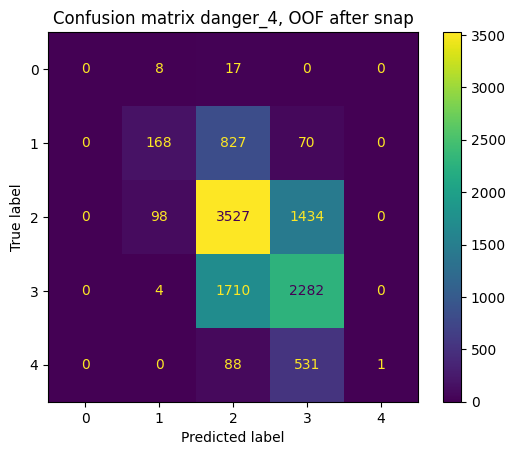

In [31]:
y4_true = np.asarray(pd.cut(y[:, D4], bins=D4_BINS, labels=False), dtype=np.int32)
y4_pred = np.asarray(pd.cut(oof_snap[:, D4], bins=D4_BINS, labels=False), dtype=np.int32)

cm = confusion_matrix(y4_true, y4_pred, labels=[0, 1, 2, 3, 4])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(6, 6))
disp.plot(values_format="d")
plt.title("Confusion matrix danger_4, OOF after snap")
plt.show()

Hasil confusion matrix menunjukkan bahwa prediksi paling banyak terkonsentrasi pada kelas 2 dan 3, yang juga sejalan dengan dominasi kedua kelas tersebut pada data. Kesalahan yang paling sering terjadi adalah pertukaran antara kelas 2 dan 3, terlihat dari jumlah besar pada sel true 2 diprediksi 3 dan true 3 diprediksi 2, yang berarti model sering bergeser satu level di sekitar boundary tengah. Kesalahan ekstrem seperti memprediksi kelas 0 atau 4 relatif jarang dibanding total sampel, sehingga sebagian besar error berasal dari ambiguitas di area transisi antar level, bukan dari prediksi yang sepenuhnya melenceng. Ini mendukung bahwa snap membantu membuat prediksi lebih konsisten secara level, namun pemisahan kelas menengah masih menjadi sumber error terbesar dan dapat menjadi fokus analisis lebih lanjut.

## Residual per target

In [29]:
resid = oof_snap - y

rows = []
for t in range(len(TARGET_COLS)):
    r = resid[:, t]
    rows.append({
        "target": TARGET_COLS[t],
        "resid_mean": float(np.mean(r)),
        "resid_std": float(np.std(r)),
        "resid_p50": float(np.median(r)),
        "resid_p95_abs": float(np.quantile(np.abs(r), 0.95)),
    })

resid_stats_df = pd.DataFrame(rows)
resid_stats_df

,target,resid_mean,resid_std,resid_p50,resid_p95_abs
0,danger_1,-0.013469,0.256279,0.000034,0.498177
1,danger_2,-0.060991,0.219070,-0.007508,0.407334
2,danger_3,-0.004495,0.116802,0.001522,0.287585
3,danger_4,-0.007370,0.703283,-0.000218,1.010557
4,danger_5,0.034274,0.272728,0.001056,0.502473


Residual dihitung sebagai prediksi OOF setelah snap dikurangi nilai true, sehingga nilai positif berarti model cenderung overpredict dan nilai negatif berarti underpredict. Secara umum, rata-rata residual untuk semua target dekat dengan nol, yang menunjukkan tidak ada bias global yang besar setelah post-processing. Danger_1, danger_2, danger_3, dan danger_4 memiliki resid_mean negatif kecil, sehingga masih ada kecenderungan underpredict tipis, sementara danger_5 memiliki resid_mean positif kecil yang mengindikasikan overpredict tipis. Nilai resid_p50 untuk semua target juga sangat dekat nol, menandakan median error terpusat dengan baik.

Dari sisi skala error, resid_p95_abs menunjukkan bahwa error besar terutama terjadi pada target yang bertingkat dan lebih sulit, yaitu danger_4, dengan nilai sekitar 1.01 pada kuantil 95 absolut. Ini sejalan dengan hasil confusion matrix yang memperlihatkan banyak perpindahan antar level berdekatan pada kelas menengah. Target lain memiliki resid_p95_abs sekitar 0.28 sampai 0.50, yang menunjukkan sebaran error lebih moderat. Dengan demikian, fokus perbaikan selanjutnya paling masuk akal diarahkan pada danger_4, terutama pada boundary antar level yang berdekatan, misalnya lewat fitur yang lebih peka terhadap region spektrum diskriminatif atau pendekatan modelling yang lebih ordinal.

## Plot scatter pred vs true per target
Plot scatter pred vs true digunakan untuk memeriksa apakah prediksi OOF setelah snap mengikuti struktur target dan untuk melihat pola bias yang masih tersisa. Karena beberapa target bersifat bertingkat atau semi diskrit, setelah snap titik titik prediksi cenderung membentuk garis horizontal pada level tertentu. Visualisasi ini membantu memastikan bahwa snap memang membuat output lebih konsisten, sekaligus menunjukkan area transisi antar level yang masih sulit dipisahkan oleh model.

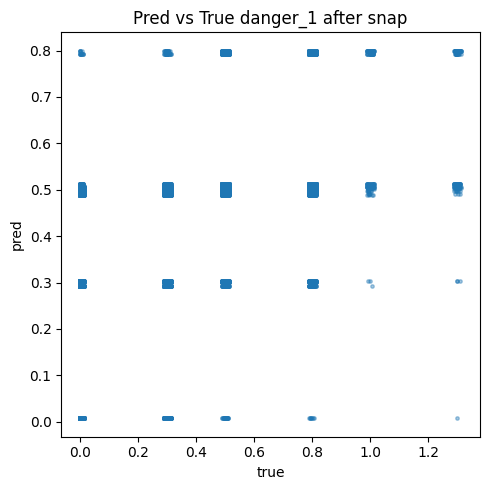

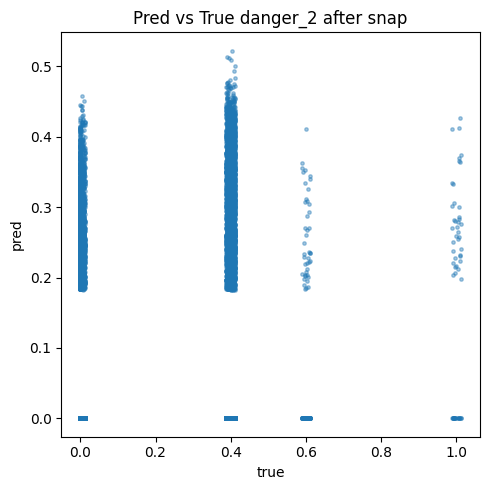

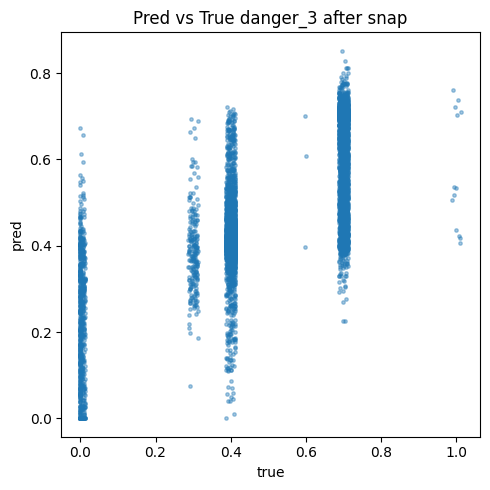

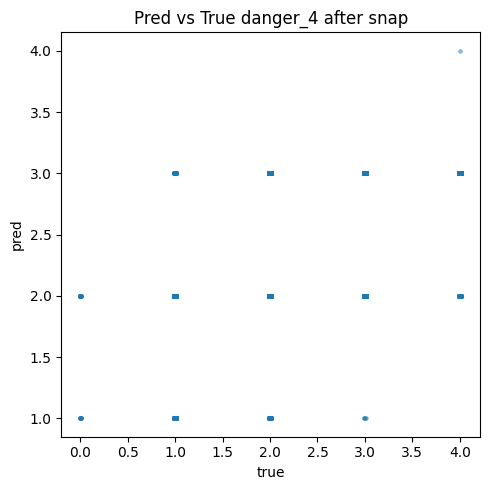

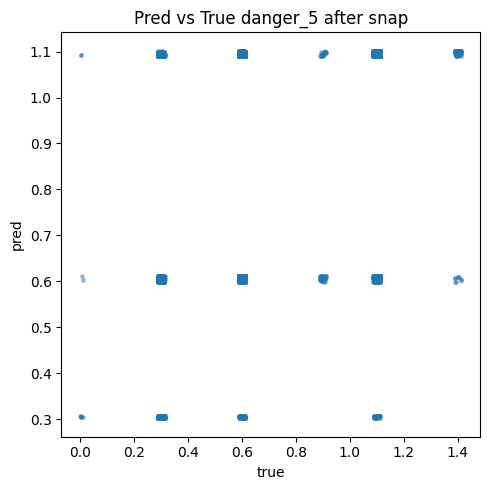

In [30]:
for t in range(len(TARGET_COLS)):
    plt.figure(figsize=(5, 5))
    plt.scatter(y[:, t], oof_snap[:, t], s=6, alpha=0.4)
    plt.title(f"Pred vs True {TARGET_COLS[t]} after snap")
    plt.xlabel("true")
    plt.ylabel("pred")
    plt.tight_layout()
    plt.show()

Hasil plot memperlihatkan bahwa setelah snap, beberapa target membentuk pola level yang jelas. Pada danger_1 dan danger_5, prediksi terlihat terkumpul pada sejumlah level diskrit yang konsisten, menandakan pred-space mapping berhasil memproyeksikan prediksi kontinu ke nilai representatif. Pada danger_2, terlihat massa besar pada true mendekati nol dan prediksi nol yang muncul setelah thresholding, serta adanya pita prediksi pada nilai non nol yang menunjukkan model membedakan sampel nol dan non nol meskipun masih ada overlap di batasnya. Pada danger_3, pola masih cenderung kontinu dan tidak dipaksa ke level tertentu, sehingga sebaran vertikal masih terlihat dan ini sejalan dengan tidak adanya snap tambahan untuk target tersebut pada tahap ini. Untuk danger_4, prediksi membentuk level bertingkat yang tegas, dan error utama tampak berasal dari perpindahan antar level berdekatan, terutama di sekitar kelas menengah, bukan dari prediksi yang melompat jauh. Secara keseluruhan, scatter plot ini mendukung hasil ablation bahwa snap meningkatkan konsistensi prediksi terhadap struktur label, sementara kesulitan terbesar tersisa pada area boundary antar level yang berdekatan.

## Kesimpulan Hasil Studi dan Ablasi
Studi ablation menunjukkan bahwa post-processing snap per target memberikan peningkatan yang konsisten dan signifikan terhadap performa OOF. Rata-rata MAE turun dari 0.223334 menjadi 0.205213, dengan perbaikan terbesar berasal dari danger_4 dan danger_5, yang memang memiliki struktur label bertingkat atau semi diskrit sehingga paling diuntungkan oleh pemetaan level dan pred-space snapping. Visualisasi confusion matrix dan scatter plot mengindikasikan bahwa setelah snap, sebagian besar kesalahan tersisa adalah perpindahan antar level yang berdekatan, terutama pada kelas menengah, sementara kesalahan ekstrem relatif jarang. Analisis residual juga menunjukkan bias rata-rata yang kecil pada semua target, sehingga peningkatan berikutnya lebih mungkin berasal dari peningkatan daya pisah di boundary antar level, bukan dari koreksi bias global. Temuan ini menguatkan keputusan menggunakan pipeline target-specific, yaitu model regresi sebagai backbone dan snap sebagai komponen penting untuk menyelaraskan prediksi dengan struktur target.

# Kesimpulan
Bagian ini merangkum hasil utama dari seluruh rangkaian analisis, mulai dari pemeriksaan kualitas data, eksplorasi karakter target, hingga evaluasi performa model. Dari EDA terlihat bahwa setiap target memiliki pola distribusi yang khas dan tidak sepenuhnya kontinu, sehingga pendekatan tunggal untuk semua target kurang optimal. Eksperimen preprocessing dan feature engineering menunjukkan bahwa normalisasi seperti SNV memberi perbaikan yang konsisten, lalu peningkatan terbesar datang dari strategi modelling yang disesuaikan per target, terutama melalui post-processing snap. Secara keseluruhan, hasil ablation dan error analysis mengindikasikan bahwa perbaikan skor bukan hanya karena model backbone, tetapi karena pemahaman struktur label dan cara mengubah prediksi menjadi level yang sesuai dengan sifat target. Berikut adalah poin-poin berkaitan dengan kompterisi ini: 

1. Masalah inti bukan cuma model, tapi struktur label per target.Kelima target tidak benar benar kontinu, histogram dan statistik menunjukkan puncak tajam di level tertentu, dengan karakter yang berbeda antar target. 

2. Dataset rapi dan siap modelling tanpa imputasi.Data train berisi 10.765 sampel, 1.800 fitur spektrum, dan 5 target, test 2.153 sampel, tidak ada nilai null, dan kolom spektrum sudah dicek konsisten. 

3. SNV layak dijadikan default karena memperbaiki MAE secara konsisten. Eksperimen awal menunjukkan SNV menurunkan MAE di seluruh target sehingga dipakai sebagai input utama pada eksperimen berikutnya agar pembahasan fokus ke perubahan model dan post-processing. 

4. Sinyal spektral paling informatif terkonsentrasi di region tertentu. Analisis spektrum per kelas danger_4 menunjukkan pemisahan kelas paling kuat muncul di sekitar indeks 1.200–1.400, dengan region paling diskriminatif terkonsentrasi sekitar 1.401–1.411. 

5. Pipeline target-specific snap adalah kontributor terbesar peningkatan skor. Snap yang dipakai mengikuti karakter target:
    - danger_1 memakai pred-space binning dan mapping median, best n_classes 20, MAE turun dari 0.196407 ke 0.185665 <br>
    - danger_2 memakai thresholding ke nol, best thr0 0.183, MAE turun dari 0.164596 ke 0.155835 <br>
    - danger_4 memakai level mapping dan tuning 4 threshold, MAE turun dari 0.511183 ke sekitar 0.4646 <br>
    - danger_5 memakai pred-space cross-fit plus snap_exact, best n_bins 40, MAE turun dari 0.180009 ke 0.155250 <br><br>


6. Ablasi mengonfirmasi snap menurunkan MAE mean secara signifikan.MAE mean turun dari 0.223334 menjadi 0.205213, delta -0.018121. Kontributor terbesar datang dari danger_4 dan danger_5. <br>

7. Error yang tersisa dominan di boundary level berdekatan, terutama danger_4. Confusion matrix menunjukkan pertukaran terbesar terjadi antara kelas 2 dan 3, artinya error lebih banyak berupa geser satu level di area tengah, bukan lompatan jauh. <br>

8. Residual juga menunjukkan bias rata-rata kecil, sehingga improvement berikutnya lebih mungkin datang dari peningkatan separasi boundary, bukan koreksi bias global.

## Kelemahan dan Constraint
Walaupun pipeline yang dibangun mampu menurunkan error secara berarti, masih ada beberapa keterbatasan yang memengaruhi batas performa. Tantangan terbesar muncul dari ketidakseimbangan kelas yang ekstrem pada target tertentu, serta sifat ordinal yang membuat kesalahan di boundary level sangat sensitif terhadap sedikit pergeseran prediksi. Selain itu, beberapa komponen post-processing berpotensi menambah bias evaluasi bila tidak selalu dirancang dengan skema cross-fit yang ketat. Di sisi lain, ruang eksplorasi fitur masih relatif konservatif karena fokus utama diarahkan pada stabilitas baseline dan efektivitas snap, sehingga pendekatan yang lebih spesifik terhadap region spektrum informatif belum sepenuhnya dimanfaatkan. Keterbatasan waktu komputasi juga membatasi cakupan tuning dan eksplorasi model yang lebih kompleks. Berikut poin - poin constraitnya:

1. Label imbalance yang ekstrem pada danger_4 membuat kelas minor rentan. Contoh kelas 0 hanya 25 sampel, jauh lebih kecil dibanding kelas 2 dan 3, sehingga sinyal kelas minor mudah tenggelam. 

2. Model backbone masih regresi umum, belum benar benar ordinal untuk danger_4. Walau snap membuat output bertingkat, error terbesar tetap ada di boundary kelas menengah. 

3. Snap berisiko jadi sumber leakage bila tidak cross-fit. danger_5 sudah cross-fit untuk mengurangi bias, tetapi konsep ini belum diterapkan merata ke target lain, sehingga fairness evaluasi bisa ditingkatkan. 

4. Eksplorasi feature engineering masih terbatas pada transformasi umum. fokus utama improvement berada pada snap dan setting CV, sehingga ruang eksplorasi fitur berbasis region diskriminatif belum dimaksimalkan. 

5. Tradeoff performa vs waktu training membatasi pencarian model yang lebih kaya. Beberapa konfigurasi lebih kuat memberi improvement di target tertentu namun menaikkan waktu latih, sehingga ruang tuning tidak sepenuhnya dieksplorasi.


## Further Works

Arah pengembangan berikutnya berfokus pada memperkuat kesesuaian metode dengan sifat target, meningkatkan robustness evaluasi, dan mengekstrak informasi spektral secara lebih terarah. Karena error dominan masih terjadi pada boundary level yang berdekatan, terutama pada target yang bersifat ordinal, maka pendekatan end to end yang benar benar ordinal berpotensi memberi peningkatan paling relevan. Selain itu, strategi kalibrasi dan snap dapat dibuat lebih fair dan stabil dengan memperluas prinsip cross-fit ke seluruh target. Dari sisi fitur, temuan region spektrum yang diskriminatif membuka peluang untuk membangun fitur ringkas yang lebih informatif dibanding hanya transformasi umum. Terakhir, eksplorasi model alternatif dan prosedur validasi yang lebih kuat akan membantu memastikan bahwa improvement yang diperoleh bukan sekadar hasil split tertentu, tetapi konsisten di berbagai kondisi. Poin - poinnya sebagai berikut

1. Bahas danger_4 sebagai ordinal end to end, bukan regresi lalu snap. Coba ordinal regression yang eksplisit, misalnya cascade binary atau pendekatan threshold model, agar boundary kelas 2–3 lebih tajam sejak training. Ini langsung menarget sumber error terbesar. 

2. Perluas cross-fit calibration untuk target lain. Terapkan cross-fit juga pada pred-space mapping danger_1, dan tuning threshold danger_2, agar post-processing selalu dipelajari dari fold train dan diaplikasikan ke fold valid, seperti yang sudah dilakukan untuk danger_5. 

3. Feature engineering fokus region informatif 1.200–1.400. Buat fitur ringkas yang mengekstrak informasi puncak di region ini, misalnya integrasi area, rasio puncak, slope lokal, atau derivative terlokalisasi, karena region ini yang paling diskriminatif untuk danger_4. 

4. Tangani zero inflation danger_2 dengan model dua tahap. Tahap 1 klasifikasi nol vs non nol, tahap 2 regresi untuk nilai non nol. Ini selaras dengan temuan bahwa error banyak datang dari prediksi kecil dekat nol. 

5. Perbaiki evaluasi dan robustness. Tambahkan repeated CV atau seed ensemble untuk mengukur stabilitas, lalu validasi apakah parameter snap seperti thr0 dan threshold danger_4 stabil lintas split.


# Referensi
Barnes, R. J., Dhanoa, M. S., & Lister, S. J. (1989). Standard normal variate transformation and de-trending of near-infrared diffuse reflectance spectra. Applied Spectroscopy, 43(5), 772–777. 

Chernozhukov, V., Chetverikov, D., Demirer, M., Duflo, E., Hansen, C., Newey, W., & Robins, J. (2018). Double/debiased machine learning for treatment and structural parameters. The Econometrics Journal, 21(1), C1–C68. 

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming with NumPy. Nature, 585, 357–362. 

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90–95.

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. Advances in Neural Information Processing Systems, 30, 3146–3154.

Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. In Proceedings of the 14th International Joint Conference on Artificial Intelligence (Vol. 2, pp. 1137–1143). Morgan Kaufmann.

McKinney, W. (2010). Data structures for statistical computing in Python. In Proceedings of the 9th Python in Science Conference (pp. 56–61). 

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12(85), 2825–2830.

Platt, J. (1999). Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods. In A. Smola, P. Bartlett, B. Schölkopf, & D. Schuurmans (Eds.), Advances in large margin classifiers (pp. 61–74). MIT Press.

Prokhorenkova, L. O., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). CatBoost: Unbiased boosting with categorical features. Advances in Neural Information Processing Systems, 31, 6639–6649.

Savitzky, A., & Golay, M. J. E. (1964). Smoothing and differentiation of data by simplified least squares procedures. Analytical Chemistry, 36(8), 1627–1639. 

Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. In Proceedings of the Eighth ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 694–699). ACM.